# Text Classification on Social Media Commentary

Assignment devoloped by António Romão (up202108704), Guilherme Gonçalves (up202107768) and Pedro Leitão (up202107852) for the Natural Language Processing course at FEUP.

## Table of Contents
1. [Introduction](#1-introduction)
    - 1.1. [Context and Problem Statement](#11-context-and-problem-statement)
    - 1.2. [Assignment Objectives](#12-assignment-objectives)
2. [Data Provenance and Characteristics](#2-data-provenance-and-characteristics)
    - 2.1. [Origin and Collection Methods](#21-origin-and-collection-methods)
    - 2.2. [Annotation Methodology](#22-annotation-methodology)
    - 2.3. [Label Definitions](#23-label-definitions)
    - 2.4. [Initial Processing and Structure](#24-initial-processing-and-structure)
3. [Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
    - 3.1. [Dataset Overview and Splits](#31-dataset-overview-and-splits)
    - 3.2. [Class Distribution and Balance](#32-class-distribution-and-balance)
    - 3.3. [Text Length Analysis](#33-text-length-analysis)
        - 3.3.1. [Overall Length Distribution](#331-overall-length-distribution)
        - 3.3.2. [Length Distribution by Class](#332-length-distribution-by-class)
    - 3.4. [Lexical Analysis and Word Distribution](#34-lexical-analysis-and-word-distribution)
        - 3.4.1. [Most Frequent Words (N-grams)](#341-most-frequent-words-n-grams)
        - 3.4.2. [TF-IDF Analysis](#342-tf-idf-analysis)
    - 3.5. [Special Tokens, Artifacts and Language Analysis](#35-special-tokens-artifacts-and-language-analysis)
4. [Data Pre-processing](#4-data-pre-processing)
    - 4.1. [Review of Inherited Processing (Baseline)](#41-review-of-inherited-processing-baseline)
    - 4.2. [Text Normalization and Cleaning](#42-text-normalization-and-cleaning)
        - 4.2.1. [Contraction Expansion](#421-contraction-expansion)
        - 4.2.2. [Selective Ponctuation and Special Character Removal](#422-selective-punctuation-and-special-character-removal)
    - 4.3. [Tokenization Strategy](#43-tokenization-strategy)
    - 4.4. [Stop Word and Domain-Specific Filler Removal](#44-stop-word-and-domain-specific-filler-removal)
    - 4.5. [Lemmatization vs. Stemming](#45-lemmatization-vs-stemming)
5. [Feature Extraction and Representation](#5-feature-extraction-and-representation)
    - 5.1. [Sparse Feature Representations (TF-IDF)](#51-sparse-feature-representations-tf-idf)
    - 5.2. [Dense Feature Representations (Word Embeddings)](#52-dense-feature-representations-word-embeddings)
    - 5.3. [Integration of Engineered Meta-Features](#53-integration-of-engineered-meta-features)
6. [Model Training and Selection](#6-model-training-and-selection)
    - 6.1. [Loading the Pre-processed Features](#61-loading-the-processed-features)
    - 6.2. [Baselines](#62-baselines)
    - 6.3. [Training a Family of Traditional Classifiers](#63-training-a-family-of-traditional-classifiers)
    - 6.4. [Hyperparameter Tuning of the Best Candidate](#64-hyperparameter-tuning-of-the-best-candidate)
7. [Model Evaluation](#7-model-evaluation)
    - 7.1. [Test-Set Metrics for Baselines and Final Model](#71-test-set-metrics-for-baselines-and-final-model)
    - 7.2. [Confusuion Matrix fot the Final Model](#72-confusion-matrix-for-the-final-model)
8. [Error Analysis](#8-error-analysis)
    - 8.1. [Top Confused Class Pairs](#81-top-confused-class-pairs)
    - 8.2. [Qualitative Inspection of Misclassified Examples](#82-qualitative-inspection-of-misclassified-examples)
    - 8.3. [Most Informative Features per Class](#83-most-informative-features-per-class)
9. [Related Work Comparison](#9-related-work-comparison)
    - 9.1. [Directly Comparable Models on this Dataset](#91-directly-comparable-models-on-this-dataset)
    - 9.2. [Head-to-head Comparison](#92-head-to-head-comparison)
    - 9.3. [What the Comparison actually shows](#93-what-the-comparison-actually-shows)
    - 9.4. [Other Reference Families](#94-other-reference-families)
    - 9.5. [Framing our Contribution](#95-framing-our-contribution)
10. [Conclusion](#10-conclusion)

## 1. Introduction

[[go back to top]](#table-of-contents)

This report presents the development and evaluation of Natural Language Processing (NLP) classifiers designed for a specialized text classification task. The introduction is divided into two main parts: first, it establishes the context and outlines the core problem by exploring the nuances of the provided social media commentary dataset; second, it details the specific academic objectives, scope, and technical constraints required for this assignment.

### 1.1. Context and Problem Statement

[[go back to section]](#1-introduction)

The landscape of online discourse is complex, and traditional sentiment analysis, often limited to simple 'positive', 'negative', or 'neutral' labels, is frequently insufficient for capturing the true nature of social media commentary. To better understand how users interact, debate, and communicate online, it is necessary to analyze the rhetorical purpose and communicative intent behind the text. 

The dataset provided for this assignment addresses this need by categorizing social media comments into five distinct, nuanced labels: Argumentative, Informational, Opinion, Expressive, and Neutral. These comments were specifically gathered using the search queries 'politics' or 'US Politics'. To ensure a diverse representation of online behavior, the data was sourced from multiple platforms with varying community norms, specifically YouTube, Hacker News, MetaFilter, Reddit, and BlueSky. The collection spans a timeframe from 2024 up to mid-February 2026.

**Problem Statement**: The core problem to be addressed in this assignment is the development of an effective Natural Language Processing (NLP) pipeline for text classification. The objective is to build robust machine learning classifiers capable of automatically categorizing these political social media comments into one of the five target labels. Successfully solving this problem involves navigating the inherent noise and variability of social media text through careful application of data pre-processing, feature extraction (including both sparse and dense representations), and traditional machine learning algorithms.

### 1.2. Assignment Objectives

[[go back to section]](#1-introduction)

The primary aim of this assignment is to build effective Natural Language Processing (NLP) classifiers for a specific text classification task. To achieve this, the project involves a comprehensive exploration of the standard NLP pipeline, including data pre-processing, feature extraction, and a comparative analysis of sparse versus dense feature representations, such as word embeddings. Prior to model development, a critical objective is to conduct an exploratory data analysis (EDA) to thoroughly understand the dataset, which includes documenting class sizes and word distributions (e.g., TF-IDF) supported by proper visualizations.

A core constraint of this project is the strict focus on "traditional" machine learning algorithms. The models explored will include classifiers such as Naive Bayes, Logistic Regression, Decision Trees, Random Forest, Support Vector Machines (SVM), Multi-Layer Perceptrons (MLP), or XGBoost. The implementation of any deep learning architectures based on Convolutional Neural Networks (CNNs), Recurrent Neural Networks (RNNs), or Transformers is explicitly prohibited for this assignment.

Finally, a rigorous evaluation methodology is required. This involves establishing a simple baseline model to benchmark future developments and reporting classifier performance using appropriate metrics such as Precision, Recall, F1, and macro-F1 scores. We will also undertake a detailed error analysis on the best-performing models to understand the reasons behind misclassifications. Furthermore, the project aims to frame our work by comparing our classifier results with any existing related work on the same problem, placing our achievements in the context of prior published research.

## 2. Data Provenance and Characteristics

[[go back to top]](#table-of-contents)

Before developing our text classifiers, the assignment requires us to establish a clear understanding of our data's provenance and inherent characteristics. To achieve this, we will examine the ADS509 Dataset, which serves as the foundation for this project. This dataset was specifically designed to capture the nuanced nature of social media commentary, moving beyond traditional 'positive', 'negative', or 'neutral' sentiment labels. The following subsections detail the sources, annotation methodology, label definitions, and initial processing steps used to construct this dataset, providing the necessary context for our subsequent exploratory data analysis and feature engineering.

### 2.1. Origin and Collection Methods

[[go back to section]](#2-data-provenance-and-characteristics)

To effectively classify the communicative intent behind online discourse, the data for this assignment was sourced from five distinct social media platforms: YouTube, Hacker News, MetaFilter, Reddit, and BlueSky. By utilizing multiple platforms, the dataset captures a wider variety of community norms and conversational styles. 

The collection focused specifically on political discussions, utilizing the targeted search queries 'politics' or 'US Politics'. The overall timeframe for the collected data ranges from 2024 to mid-February of 2026. However, the exact chronological span varies depending on the specific platform's traffic volume and API rate limits. For example, due to its heavy traffic, the Reddit collection hit daily rate limits and is consequently restricted to posts from just the first two weeks of February 2026. In contrast, data pulled from MetaFilter extends as far back as 2024.

Furthermore, specific structural filtering criteria were applied during the collection process to ensure data quality and balance:
* Posts containing fewer than 10 comments were entirely excluded from the dataset.
* A maximum threshold of 300 comments was extracted from any single post to prevent highly active or viral threads from disproportionately dominating the data distribution.

### 2.2. Annotation Methodology

[[go back to section]](#2-data-provenance-and-characteristics)


The annotation process for this dataset combined a small human-validated seed set with large-scale automated labeling by an ensemble of Large Language Models (LLMs).

First, a manual pilot annotation phase was conducted to establish the labeling criteria. A sample of 100 comments was independently labeled by two of the dataset creators, then compared and revised to resolve disagreements and solidify the definitions of the five classes.

For the remaining ~70k comments, the labeling was scaled up using a Batch API to query three distinct state-of-the-art language models: **Gemini Flash 3**, **ChatGPT 5.1**, and **Claude Haiku 4.5**.

To ensure the models accurately captured the nuanced definitions of the five classes, a few-shot prompting strategy with contrastive examples was used. Specifically, the prompt provided to each LLM included:
* 10 examples of correctly labeled samples to demonstrate the expected output.
* 10 examples of previously incorrectly labeled samples, alongside their corrected labels, to help the models avoid common classification pitfalls.

Finally, a majority-vote consensus mechanism was applied for quality control. Only comments that achieved agreement from **at least two of the three LLMs** were retained in the final dataset. Three-way ties — comments where no two models agreed — were set aside and excluded from the released splits.

**Implications for this assignment.** It is important to explicitly acknowledge that, with only 100 of ~70k comments having been labeled by humans, the ground-truth labels used for both training and evaluation are effectively **distilled from the consensus of three frontier LLMs** rather than from a traditional human annotation process. This has two consequences we will revisit in the error analysis (Section 8):

1. The practical upper bound on any classifier's performance on this dataset is bounded by the agreement rate between those three LLMs on similar comments — not by human inter-annotator agreement.
2. When we observe a "misclassification" in Section 8, we should read it as *"our classifier disagreed with the 2-of-3 LLM majority"*, which is subtly different from *"our classifier disagreed with a human"*. For comments that sit genuinely on the boundary between Opinion, Expressive, and Argumentative — the hardest region of the label space — this is a meaningful distinction.


### 2.3. Label Definitions

[[go back to section]](#2-data-provenance-and-characteristics)

The dataset categorizes social media comments into five distinct, nuanced labels, moving beyond simple sentiment analysis. Understanding the boundaries between these classes is crucial for our text classification task:

* **Argumentative:** These comments make specific claims, predictions, or assertions that are supported by reasoning. They often use evidence, anecdotes, or scenarios to build a case. The key distinction from an 'Opinion' is the clear attempt to persuade or explain the reasoning behind a position, rather than just stating it.
* **Informational:** This category includes comments that share facts, data, links, or relevant context. They typically exhibit low emotional affect, aiming solely to inform rather than to convince or react. This includes answering questions with factual content. Unlike 'Argumentative' comments, 'Informational' ones present data without advocating for a specific stance.
* **Opinion:** These comments state a value judgment, stance, or "take" without providing substantial reasoning. Examples include simple assertions like "This is good/bad/wrong/overrated". They differ from 'Argumentative' text by lacking a real attempt to support the claim, and from 'Expressive' text because they do make a specific point rather than just reacting.
* **Expressive:** This label captures emotional reactions, sarcasm, jokes, venting, and exclamations. The primary intent is to express feeling rather than to make a substantive point. It includes performative agreements or disagreements (e.g., "THIS," "lol exactly," "what a joke"). The key distinction from 'Opinion' is the absence of an identifiable stance, consisting purely of affect.
* **Neutral:** This category acts as a catch-all for comments that do not clearly fit into the other four categories. It encompasses clarifying or rhetorical questions, meta-commentary, off-topic remarks, and simple factual questions directed at other users.

### 2.4. Initial Processing and Structure

[[go back to section]](#2-data-provenance-and-characteristics)

Before applying our own specific NLP pre-processing techniques, it is important to acknowledge the initial cleaning steps and structural formatting already performed by the dataset creators. 

**Data Processing Steps:**
To ensure a cleaner baseline for text classification, the following processing actions were executed before the dataset was finalized:
* Approximately 2,000 to 3,000 duplicate comments were removed.
* Any rows containing NaN (Not a Number) values were dropped.
* Emojis were systematically converted into their corresponding text representations using the [emoji package](https://pypi.org/project/emoji/).
* All text was converted to lowercase to maintain uniformity.
* Remaining HTML artifacts were stripped from the comments.
* URL links were replaced with a generic `[URL]` tag to normalize the text and prevent the models from overfitting to specific web addresses.
* Escaped characters (e.g., `&/quot;`) were converted back to their standard text equivalents (e.g., `"`).

**Dataset Structure:**
The resulting dataset consists of two primary features: `text` (the social media comment as a string) and `label` (the assigned numeric class ID). The specific mapping of labels to their corresponding numeric IDs is as follows:
* **0**: Neutral
* **1**: Opinion
* **2**: Argumentative
* **3**: Expressive
* **4**: Informational

It is pre-divided into three standard splits to facilitate model training and evaluation:
* **Train Split:** 49,268 examples.
* **Valid Split:** 10,557 examples.
* **Test Split:** 10,558 examples.

## 3. Exploratory Data Analysis (EDA)

[[go back to top]](#table-of-contents)

In this section, we conduct a comprehensive Exploratory Data Analysis (EDA) on the ADS509 dataset to establish a robust understanding of its underlying characteristics prior to feature extraction and model development. As outlined in the assignment objectives, this analysis quantifies the dataset's scale and examines the distribution of examples across the five nuanced target labels: Neutral, Opinion, Argumentative, Expressive, and Informational. By visually exploring text length variations and word distributions (including the application of TF-IDF) across comments sourced from diverse social media platforms, we aim to uncover lexical patterns and potential class imbalances. These foundational insights will directly justify our subsequent choices in data pre-processing and the selection of appropriate traditional machine learning classifiers.

### 3.1. Dataset Overview and Splits

[[go back to section]](#3-exploratory-data-analysis-eda)

Before diving into feature distributions, it is crucial to verify the foundational structure of our dataset. Based on the dataset card, the data has already been pre-divided into three splits (train, validation, and test) and contains two primary features: the `text` of the social media comment and its corresponding numeric `label`. Furthermore, the dataset creators noted that missing values (NaNs) were already removed during their initial processing. In this section, we load the data, merge it together for further pre-processing and programmatically confirm these expected dimensions and data integrity before proceeding with further analysis.

In [1]:
import pandas as pd

# Load the dataset splits
try:
    df_train = pd.read_parquet('dataset/train-00000-of-00001.parquet')
    df_valid = pd.read_parquet('dataset/valid-00000-of-00001.parquet')
    df_test = pd.read_parquet('dataset/test-00000-of-00001.parquet')
except FileNotFoundError:
    print("Please update the file paths in the read_parquet functions to match your local directory.")

# Combine all splits into one DataFrame
df_full = pd.concat([df_train, df_valid, df_test], axis=0).reset_index(drop=True)

# 2. Check Dataset Structure and Data Types
print("\n--- Training Data Info ---")
df_full.info()

# 3. Verify the absence of Null values
print("\n--- Missing Values Check (Training Set) ---")
missing_values = df_full.isnull().sum()
print(missing_values)

# Display the first few rows to visually inspect the 'text' and 'label' features
display(df_full.head())


--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70383 entries, 0 to 70382
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    70383 non-null  object
 1   label   70383 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ MB

--- Missing Values Check (Training Set) ---
text     0
label    0
dtype: int64


,text,label
0,thank you!!!!!!!!!!!,3
1,of course they are attacking her but are perfe...,2
2,i am not aware of the us having the ability in...,1
3,"these senators are so funny, in the preceding ...",2
4,naye face_with_tears_of_joy face_with_tears_of...,3


**Observations:**

The dataset has been successfully loaded, merged and its structure verified. As stated in the dataset documentation, there are no missing values (`NaN`s) to handle. A preliminary inspection of the first few rows confirms that textual pre-processing (such as lowercasing and emoji-to-text conversion) is already present. We can now proceed to analyze the distribution of the target labels.

### 3.2. Class Distribution and Balance

[[go back to section]](#3-exploratory-data-analysis-eda)

A fundamental step in preparing for text classification is understanding the distribution of our target variable. Class imbalance can heavily skew the performance of traditional machine learning models, often causing them to over-predict the majority class. In this section, we map the numeric label IDs back to their corresponding descriptive categories (Neutral, Opinion, Argumentative, Expressive, and Informational) to visualize the balance of our training dataset.

--- Class Distribution (Training Set) ---
Expressive: 21,876 examples (31.08%)
Opinion: 21,857 examples (31.05%)
Argumentative: 15,938 examples (22.64%)
Neutral: 5,610 examples (7.97%)
Informational: 5,102 examples (7.25%)


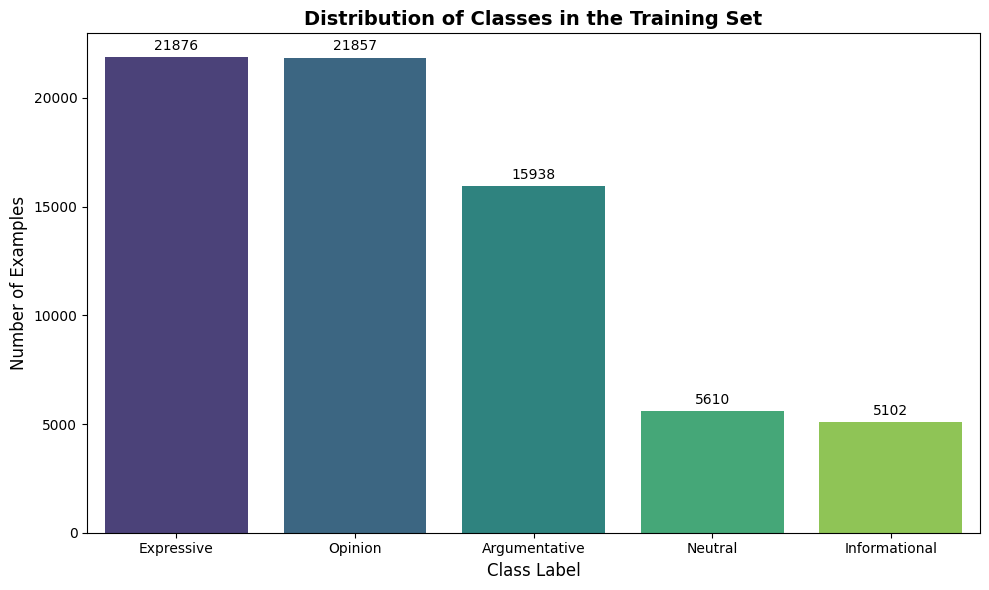

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map numeric IDs to label names based on the dataset card
id2label = {
    0: 'Neutral',
    1: 'Opinion',
    2: 'Argumentative',
    3: 'Expressive',
    4: 'Informational'
}

# Create a readable label column for EDA
df_full['label_name'] = df_full['label'].map(id2label)

# 2. Calculate counts and percentages
class_counts = df_full['label_name'].value_counts()
class_percentages = df_full['label_name'].value_counts(normalize=True) * 100

print("--- Class Distribution (Training Set) ---")
for label, count in class_counts.items():
    print(f"{label}: {count:,} examples ({class_percentages[label]:.2f}%)")

# 3. Visualize the distribution
plt.figure(figsize=(10, 6))
# Using seaborn for a clean, professional bar chart
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)

plt.title('Distribution of Classes in the Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Number of Examples', fontsize=12)

# Add count annotations on top of the bars for clarity
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 8), 
                textcoords = 'offset points')

# Clean up layout
plt.tight_layout()
plt.show()

**Observations:**

The visualization reveals a distinct class imbalance within the training dataset. The "Expressive" (31.08%) and "Opinion" (31.05%) classes heavily dominate the discourse, collectively accounting for over 62% of the data. The "Argumentative" class is also well-represented at 22.64%. Conversely, the "Neutral" (7.97%) and "Informational" (7.25%) classes form a small minority.

This distribution logically aligns with the dataset's provenance: social media discussions gathered using the search queries 'politics' or 'US Politics' naturally skew toward emotional reactions and value judgments rather than the objective sharing of facts or neutral meta-commentary. 

From a machine learning perspective, identifying this imbalance is a critical outcome of our EDA. When training our traditional classifiers, algorithms may become biased toward predicting the majority classes ("Expressive" and "Opinion") at the expense of the minority classes. To mitigate this, we will need to consider strategies such as class weighting during model training, and we must prioritize robust evaluation metrics like macro-F1 over standard accuracy to ensure our models perform well across all communicative intents.

### 3.3. Text Length Analysis

[[go back to section]](#3-exploratory-data-analysis-eda)

Understanding the physical length of the comments within our corpus is a critical step in our Exploratory Data Analysis. Text length directly informs our choices for feature extraction, particularly when determining the maximum vocabulary size or feature limits for sparse representations like TF-IDF or Count Vectorization. Furthermore, analyzing the distribution of comment lengths can reveal inherent structural differences between our target labels; for instance, "Argumentative" comments, which rely on evidence and reasoning, may naturally present as longer texts compared to the shorter, affect-driven statements typical of "Expressive" comments.

#### 3.3.1. Overall Length Distribution

[[go back to subsection]](#33-text-length-analysis)

To begin our text length analysis, we calculate both the character count and the approximated word count (via whitespace splitting) for each comment in the training set. Visualizing these overall distributions using histograms helps us identify the central tendency of the data, as well as any extreme outliers (such as unusually long rants) that might require specialized pre-processing or truncation later in the pipeline.

--- Character Count Statistics ---
count    70383.000000
mean       193.665701
std        319.081921
min          1.000000
25%         51.000000
50%        101.000000
75%        214.000000
max      12768.000000
Name: char_count, dtype: float64

--- Word Count Statistics ---
count    70383.000000
mean        33.021781
std         54.088460
min          1.000000
25%          9.000000
50%         17.000000
75%         37.000000
max       2162.000000
Name: word_count, dtype: float64


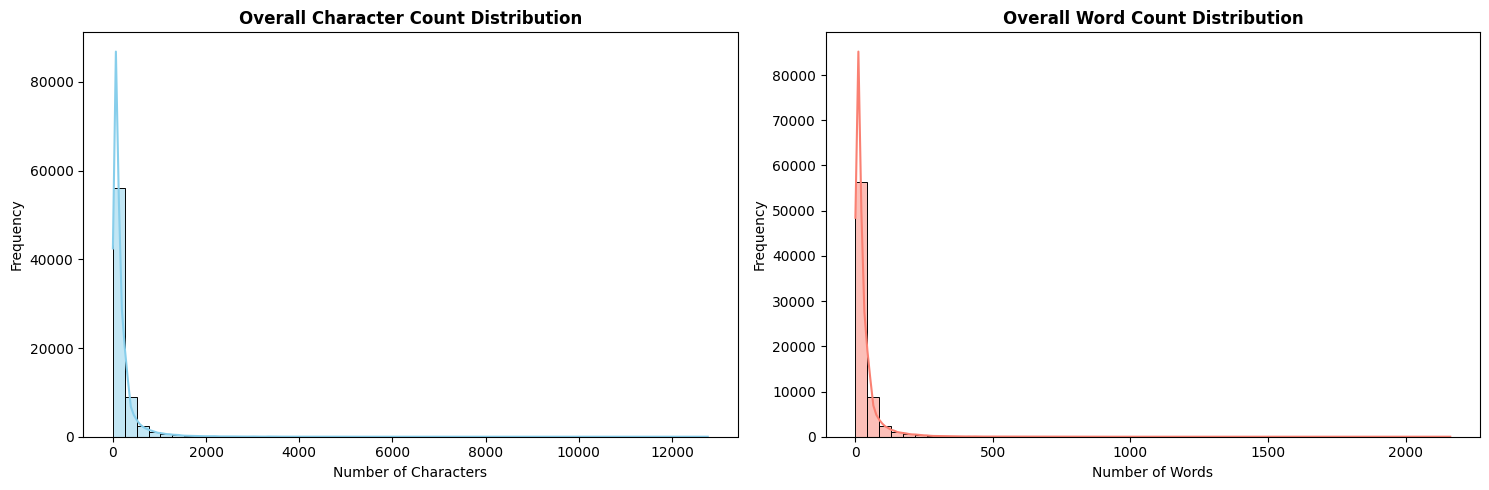

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate character count and word count for the training dataset
df_full['char_count'] = df_full['text'].apply(lambda x: len(str(x)))
df_full['word_count'] = df_full['text'].apply(lambda x: len(str(x).split()))

# Display basic statistical summaries
print("--- Character Count Statistics ---")
print(df_full['char_count'].describe())
print("\n--- Word Count Statistics ---")
print(df_full['word_count'].describe())

# Visualize the overall distributions using histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Character Count Histogram
sns.histplot(df_full['char_count'], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Overall Character Count Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

# Word Count Histogram
sns.histplot(df_full['word_count'], bins=50, ax=axes[1], color='salmon', kde=True)
axes[1].set_title('Overall Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Observations:**

The histograms and descriptive statistics reveal that both character and word counts follow a heavily right-skewed distribution. The vast majority of comments are short; the median word count is just 17 words, and 75% of the data falls under 37 words. However, the presence of extreme outliers (with a maximum of 2,162 words and 12,768 characters) pulls the mean significantly higher than the median. 

This distribution is highly characteristic of the diverse social media sources in this dataset (e.g., Reddit, YouTube, BlueSky), where discourse consists primarily of brief, rapid-fire reactions interspersed with occasional long-form rants or detailed explanations. From an NLP pipeline perspective, these extreme outliers suggest that we may need to cap maximum sequence lengths or limit vocabulary sizes during feature extraction (such as when fitting a `CountVectorizer` or `TfidfVectorizer`) to prevent our sparse matrices from expanding exponentially with rare words from these few mega-comments.

#### 3.3.2. Length Distribution by Class

[[go back to subsection]](#33-text-length-analysis)

Having established the overall right-skewed nature of the dataset, we now investigate whether text length varies significantly across our five target labels. Given the specific label definitions provided in the dataset card, it is reasonable to hypothesize that "Argumentative" and "Informational" comments, which require the presentation of facts, reasoning, and context, will inherently possess higher median word counts than "Opinion" or "Expressive" comments, which often consist of brief statements or emotional reactions. To visualize this effectively without the visual distortion caused by the extreme outliers identified in the previous section, we utilize boxplots focusing strictly on the core quartiles of the data.

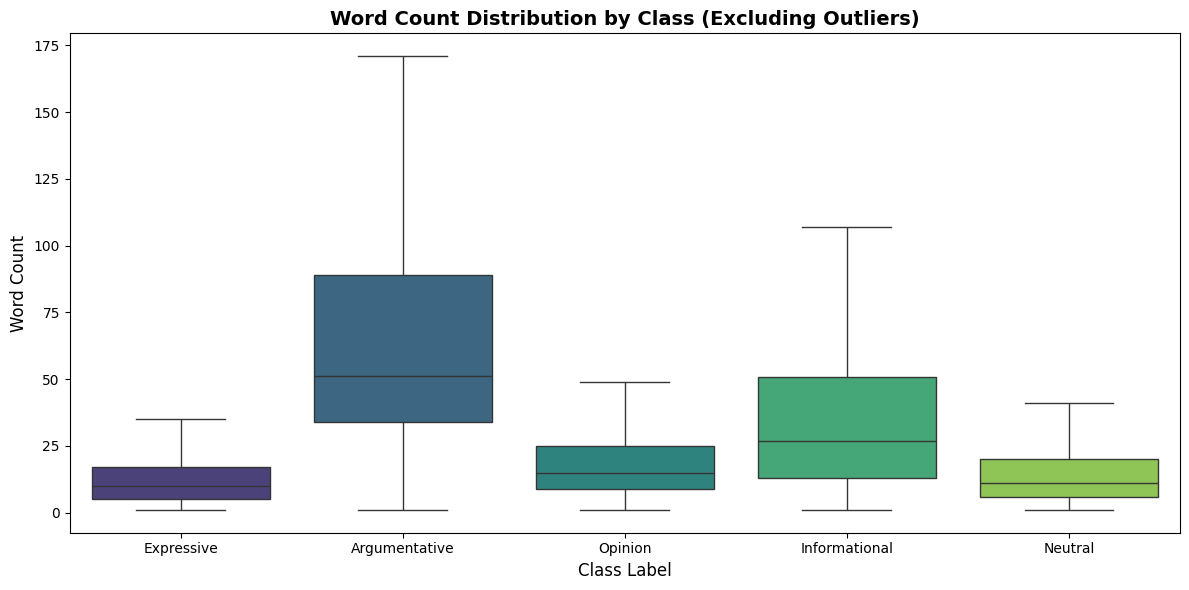

--- Median Word Count per Class ---
label_name
Argumentative    51.0
Informational    27.0
Opinion          15.0
Neutral          11.0
Expressive       10.0
Name: word_count, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot to compare word counts across classes
plt.figure(figsize=(12, 6))

# We use showfliers=False to hide the extreme outliers 
# so the core distribution (Interquartile Ranges) is clearly visible.
sns.boxplot(
    x='label_name', 
    y='word_count', 
    data=df_full, 
    palette='viridis',
    hue='label_name',
    legend=False,
    showfliers=False 
)

plt.title('Word Count Distribution by Class (Excluding Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Word Count', fontsize=12)

plt.tight_layout()
plt.show()

# Calculate and print the median word count per class to confirm the visual trends
print("--- Median Word Count per Class ---")
median_lengths = df_full.groupby('label_name')['word_count'].median().sort_values(ascending=False)
print(median_lengths)

**Observations:**

The boxplot and median word count calculations confirm a significant relationship between a comment's structural length and its specific target label. As hypothesized, the "Argumentative" class exhibits a substantially higher median (51 words) and a much wider interquartile range compared to the other categories. This aligns perfectly with its definition of using evidence, scenarios, and reasoning to build a persuasive case. 

Similarly, the "Informational" class, which focuses on sharing facts and context, shows the second-highest median (27 words). In stark contrast, the "Opinion" (15 words), "Neutral" (11 words), and "Expressive" (10 words) classes are characterized by their brevity, reflecting their nature as quick value judgments, meta-commentary, or purely emotional reactions. 

From an NLP perspective, this is a highly valuable finding. It strongly suggests that "text length" (either raw word count or character count) is a highly discriminative feature. When building our traditional machine learning models (such as Logistic Regression or a Random Forest classifier), appending the raw word count as a dense feature alongside our sparse text representations (like TF-IDF) could notably improve the model's ability to distinguish between "Argumentative" and "Expressive" comments.

### 3.4. Lexical Analysis and Word Distribution

[[go back to section]](#3-exploratory-data-analysis-eda)

Having explored the macro-level characteristics of our dataset, such as class balance and text length, we now shift our focus to the actual content of the comments. A core requirement of this exploratory data analysis is to understand the word distribution across the corpus. By analyzing the most frequent terms (N-grams) and applying techniques like Term Frequency-Inverse Document Frequency (TF-IDF), we can uncover the distinct lexical patterns and vocabulary choices that characterize our five target labels. This lexical analysis will directly inform our subsequent decisions regarding text pre-processing (such as stop-word removal) and feature representation.

#### 3.4.1. Most Frequent Words (N-grams)

[[go back to subsection]](#34-lexical-analysis-and-word-distribution)

Before applying more complex transformations, it is highly beneficial to look at the raw frequency of words (unigrams) and two-word combinations (bigrams) across the dataset. We will use a basic count vectorization approach, initially filtering out standard English stop words, to identify the dominant themes in the political discourse captured in this dataset. Identifying these highly frequent terms helps us verify if platform-specific artifacts or generic political jargon dominate the text, which will guide our feature extraction strategy.

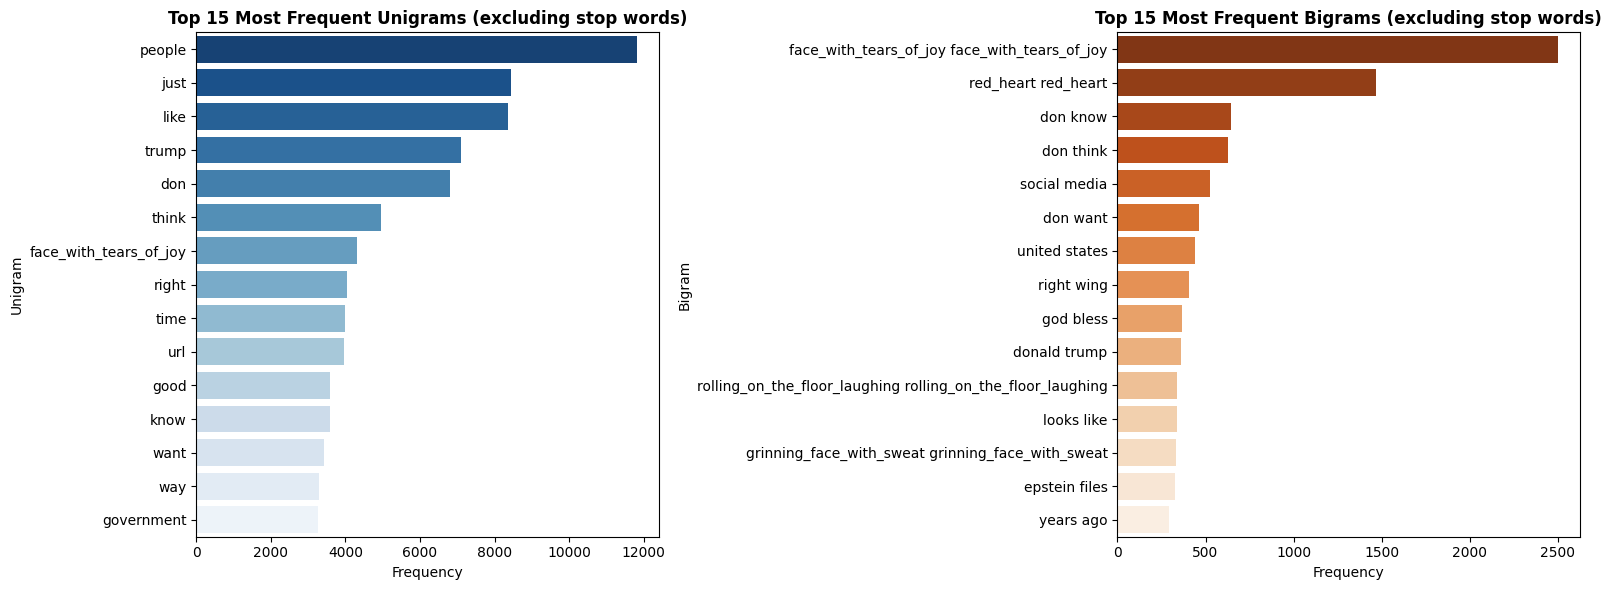

--- Top 5 Unigrams ---
  Unigram  Frequency
0  people      11816
1    just       8435
2    like       8361
3   trump       7093
4     don       6810

--- Top 5 Bigrams ---
                                          Bigram  Frequency
0  face_with_tears_of_joy face_with_tears_of_joy       2501
1                            red_heart red_heart       1466
2                                       don know        642
3                                      don think        626
4                                   social media        525


In [5]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def get_top_n_grams(corpus, n=1, top_k=15):
    """
    Helper function to extract the top k most frequent n-grams from a text corpus.
    We use stop_words='english' to filter out common words like 'the', 'is', 'and'.
    """
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Extract top unigrams (1 word) and bigrams (2 words) from the training text
top_unigrams = get_top_n_grams(df_full['text'].dropna(), n=1, top_k=15)
top_bigrams = get_top_n_grams(df_full['text'].dropna(), n=2, top_k=15)

# Convert to DataFrames for easier plotting
df_unigrams = pd.DataFrame(top_unigrams, columns=['Unigram', 'Frequency'])
df_bigrams = pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency'])

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Unigrams
sns.barplot(x='Frequency', y='Unigram', data=df_unigrams, ax=axes[0], palette='Blues_r', hue='Unigram', legend=False)
axes[0].set_title('Top 15 Most Frequent Unigrams (excluding stop words)', fontweight='bold')

# Plot Bigrams
sns.barplot(x='Frequency', y='Bigram', data=df_bigrams, ax=axes[1], palette='Oranges_r', hue='Bigram', legend=False)
axes[1].set_title('Top 15 Most Frequent Bigrams (excluding stop words)', fontweight='bold')

plt.tight_layout()
plt.show()

# Display the raw data as well
print("--- Top 5 Unigrams ---")
print(df_unigrams.head())
print("\n--- Top 5 Bigrams ---")
print(df_bigrams.head())

**Observations:**

The frequency analysis of unigrams and bigrams provides several critical insights into the dataset's lexical landscape:

1. **Impact of Pre-processing:** The dataset creators explicitly noted that emojis were converted to text and URLs were replaced with a `[URL]` tag. We can see the direct result of this here: `url` is one of the top unigrams, and emoji strings like `face_with_tears_of_joy` and `red_heart` dominate the charts. In fact, repeated emojis (e.g., `face_with_tears_of_joy face_with_tears_of_joy`) are the most frequent bigrams by a massive margin. Given the high volume of the "Expressive" class, these emoji tokens will likely be highly predictive features for our models.
2. **Tokenization Artifacts:** The presence of the unigram `don` (and bigrams like `don think`, `don know`) indicates that punctuation removal during standard tokenization split contractions like "don't". 
3. **Domain Confirmation:** Terms like `trump`, `government`, `united states`, and `right wing` validate the dataset's political scope. 
4. **The Need for Advanced Representation:** Despite removing standard English stop words, colloquial conversational fillers (`just`, `like`, `people`, `think`, `know`) still dominate the top frequencies. Because these terms likely appear uniformly across all classes, they might not be very discriminative for our classifiers. 

This final observation strongly justifies our next step. To filter out these pervasive but uninformative fillers and uncover the truly unique vocabulary of each target label, we must transition from raw counts to Term Frequency-Inverse Document Frequency (TF-IDF) weighting.

#### 3.4.2. TF-IDF Analysis

[[go back to subsection]](#34-lexical-analysis-and-word-distribution)

As observed in our N-gram analysis, raw frequency counts are often dominated by common conversational fillers and ubiquitous emojis, which offer little discriminative power for classification. To uncover the distinctive vocabulary of each target label, we apply Term Frequency-Inverse Document Frequency (TF-IDF) weighting. 

By aggregating all comments within a given class into a single "macro-document" and calculating TF-IDF scores across these five documents, we can penalize terms that are common across the entire political discourse and highlight the unique lexical signatures of each communicative intent. We visualize these class-specific TF-IDF scores using WordClouds, where the size of a word corresponds to its discriminative importance rather than just its raw frequency.

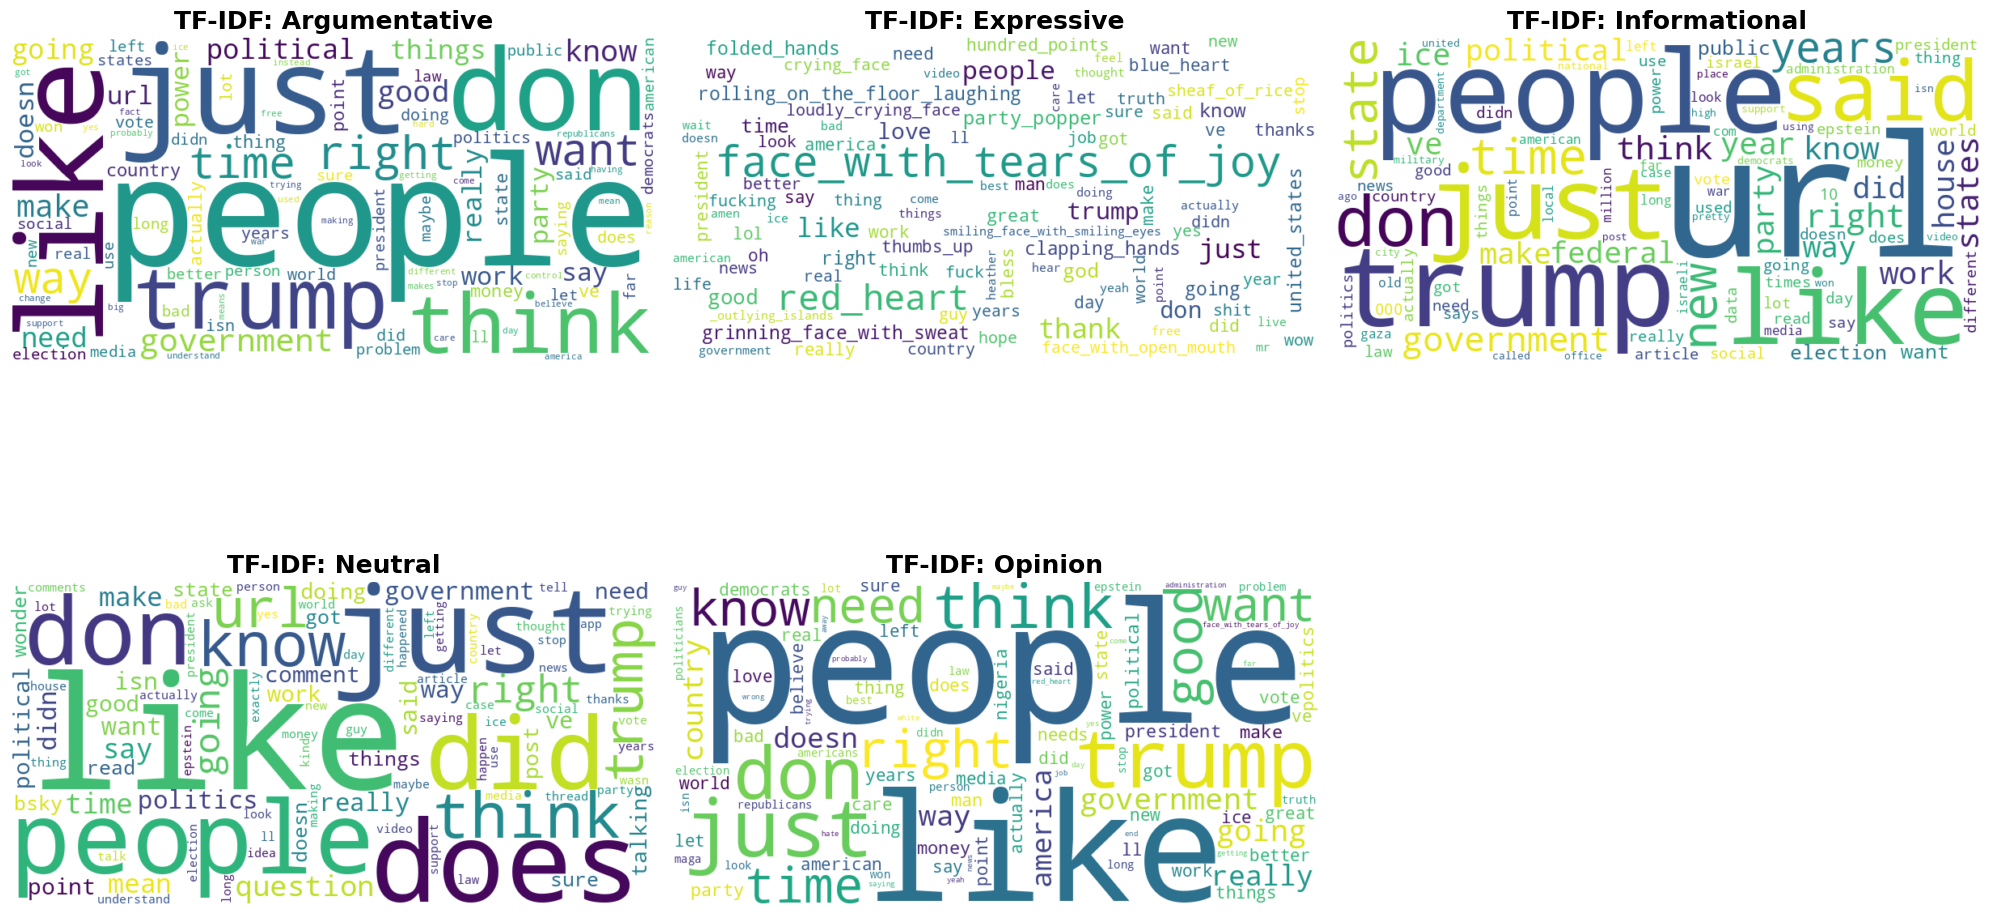

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Combine all text per class to create 5 "macro-documents"
# We drop any lingering NaNs in the text column just to be safe.
class_texts = df_full.dropna(subset=['text']).groupby('label_name')['text'].apply(lambda x: ' '.join(x))

# 2. Initialize and fit the TF-IDF Vectorizer
# We limit to 2000 features to keep the clouds focused on the most important terms
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=2000)
tfidf_matrix = tfidf_vectorizer.fit_transform(class_texts)
feature_names = tfidf_vectorizer.get_feature_names_out()

# 3. Generate WordClouds for each class
# We create a 2x3 grid to hold our 5 visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (label, _) in enumerate(class_texts.items()):
    # Get the TF-IDF scores for the current class (row i in the matrix)
    row = tfidf_matrix[i].toarray().flatten()
    
    # Create a dictionary of {word: tf-idf_score} for the WordCloud
    word_scores = {feature_names[j]: row[j] for j in range(len(feature_names)) if row[j] > 0}
    
    # Generate the WordCloud based on these frequencies
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap='viridis',
                          max_words=100).generate_from_frequencies(word_scores)
    
    # Plotting
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'TF-IDF: {label}', fontsize=18, fontweight='bold')
    axes[i].axis('off')

# Hide the 6th (empty) subplot since we only have 5 classes
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**Observations:**

The class-specific TF-IDF WordClouds reveal highly distinct lexical signatures that align perfectly with the label definitions provided in the dataset documentation:

1. **Expressive:** This class is overwhelmingly dominated by emoji text strings (e.g., `face_with_tears_of_joy`, `red_heart`, `party_popper`) and reactive language (e.g., "lol", profanities). This mathematically confirms its definition as a category driven by emotional reactions and performative affect rather than substantive points.
2. **Informational:** The most prominent feature here is the `url` token, highlighting the dataset's pre-processing step where links were replaced with this tag. Paired with reporting verbs like `said` and objective nouns like `state`, `new`, and `years`, this solidifies the class's intent to share facts, data, and context.
3. **Neutral:** This category distinctly features meta-commentary vocabulary such as `post`, `thread`, and `video`, alongside question-oriented words (`does`, `did`, `mean`). This directly supports its role as a catch-all for clarifying questions and off-topic remarks.
4. **Opinion vs. Argumentative:** While both classes share generic political vocabulary (`people`, `trump`, `government`), the "Opinion" cloud shows a stronger emphasis on simple value judgments (`good`, `bad`, `right`). 

**Conclusion on Lexical Features:** By applying TF-IDF, we have successfully transformed our raw text into a highly discriminative feature space. The presence of specific tokens (like `url` for Informational or `face_with_tears_of_joy` for Expressive) will serve as incredibly strong signals for our traditional machine learning classifiers (such as Naive Bayes or SVMs) in the modeling phase.

### 3.5. Special Tokens, Artifacts, and Language Analysis

[[go back to section]](#3-exploratory-data-analysis-eda)

During the initial data collection and processing phase, the dataset creators applied specific transformations: URL links were replaced with a standard `[URL]` tag, and emojis were converted into their descriptive text equivalents (e.g., `face_with_tears_of_joy`). Furthermore, the assignment requires us to understand the language coverage of our corpus. 

In this section, we analyze the distribution of these specific artifacts across our five target labels. We hypothesize that "Informational" comments will exhibit a high frequency of URL tags, while "Expressive" comments will be heavily saturated with emoji text, as highlighted by the previous subsection. Additionally, to accurately quantify the presence of non-Latin/multilingual discourse, we use a targeted regular expression to detect specific non-Latin alphabets (such as Cyrillic, Arabic, CJK ideographs, Greek, and Hebrew), ensuring we do not accidentally flag standard English "smart punctuation" or formatting artifacts.

--- Percentage of Comments Containing a URL ---
label_name
Informational    24.049392
Argumentative     5.038273
Neutral           2.745098
Expressive        0.530261
Opinion           0.489546
Name: contains_url, dtype: float64

--- Average Number of Emojis per Comment ---
label_name
Expressive       0.763759
Opinion          0.095988
Neutral          0.046524
Argumentative    0.044673
Informational    0.035476
Name: emoji_count, dtype: float64

--- Percentage of Comments Containing Foreign Scripts (Cyrillic, Arabic, CJK, etc.) ---
label_name
Expressive       0.283416
Neutral          0.267380
Opinion          0.164707
Informational    0.137201
Argumentative    0.062743
Name: has_foreign_script, dtype: float64


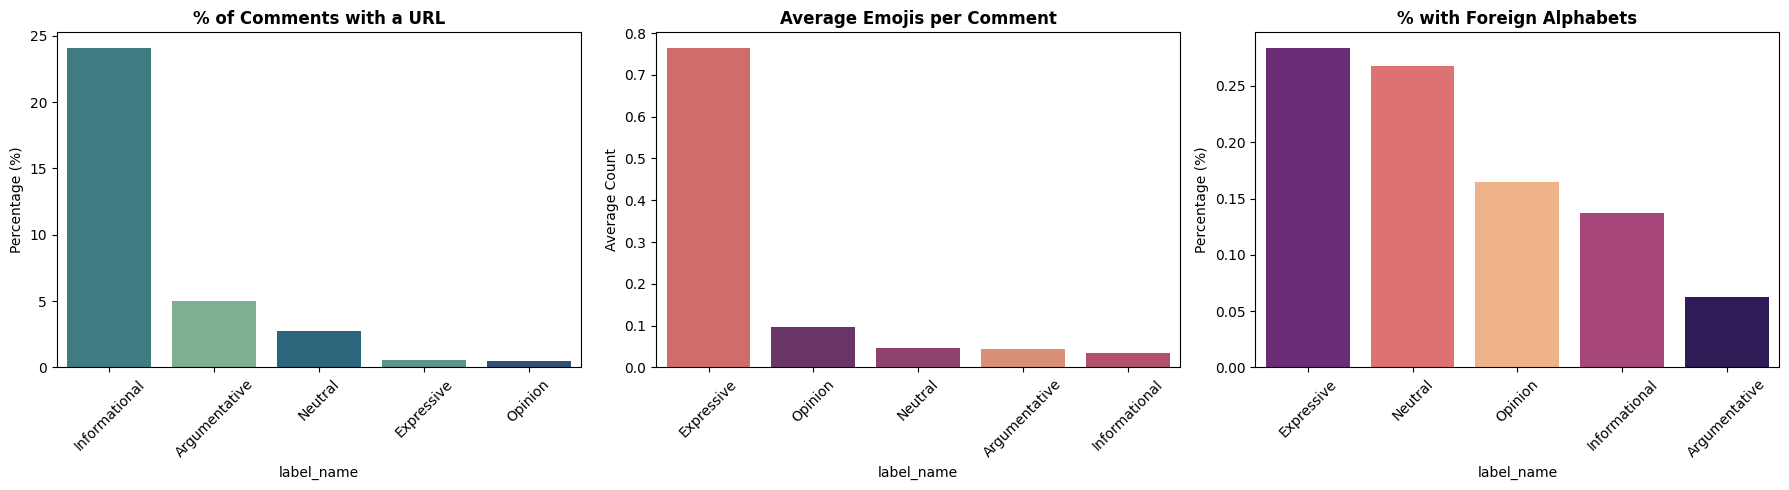

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd

# 1. Feature Engineering: Extract Special Tokens & Language Scripts
df_full['contains_url'] = df_full['text'].astype(str).str.contains(r'\[url\]|\burl\b', case=False, regex=True)

def count_emojis(text):
    matches = re.findall(r'\b\w+_\w+\b', str(text))
    return len(matches)

df_full['emoji_count'] = df_full['text'].apply(count_emojis)

# 2. Targeted Foreign Script Detection
# Instead of catching all non-ASCII (which catches smart quotes and dashes), 
# we explicitly target the Unicode blocks for major non-Latin alphabets:
# Cyrillic (\u0400-\u04FF), Arabic (\u0600-\u06FF), Greek (\u0370-\u03FF), 
# Hebrew (\u0590-\u05FF), and CJK/Asian scripts (\u3040-\u30FF, \u4E00-\u9FFF, \uAC00-\uD7AF)
foreign_script_regex = r'[\u0400-\u04FF\u0600-\u06FF\u0370-\u03FF\u0590-\u05FF\u3040-\u30FF\u4E00-\u9FFF\uAC00-\uD7AF]'
df_full['has_foreign_script'] = df_full['text'].astype(str).str.contains(foreign_script_regex, regex=True)

# 3. Calculate Grouped Statistics
url_stats = df_full.groupby('label_name')['contains_url'].mean() * 100
emoji_stats = df_full.groupby('label_name')['emoji_count'].mean()
foreign_stats = df_full.groupby('label_name')['has_foreign_script'].mean() * 100

print("--- Percentage of Comments Containing a URL ---")
print(url_stats.sort_values(ascending=False))
print("\n--- Average Number of Emojis per Comment ---")
print(emoji_stats.sort_values(ascending=False))
print("\n--- Percentage of Comments Containing Foreign Scripts (Cyrillic, Arabic, CJK, etc.) ---")
print(foreign_stats.sort_values(ascending=False))

# 4. Visualize the Results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot URL Distribution
sns.barplot(x=url_stats.index, y=url_stats.values, ax=axes[0], palette='crest', order=url_stats.sort_values(ascending=False).index, hue=url_stats.index, legend=False)
axes[0].set_title('% of Comments with a URL', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=45)

# Plot Emoji Distribution
sns.barplot(x=emoji_stats.index, y=emoji_stats.values, ax=axes[1], palette='flare', order=emoji_stats.sort_values(ascending=False).index, hue=emoji_stats.index, legend=False)
axes[1].set_title('Average Emojis per Comment', fontweight='bold')
axes[1].set_ylabel('Average Count')
axes[1].tick_params(axis='x', rotation=45)

# Plot Foreign Script Distribution
sns.barplot(x=foreign_stats.index, y=foreign_stats.values, ax=axes[2], palette='magma', order=foreign_stats.sort_values(ascending=False).index, hue=foreign_stats.index, legend=False)
axes[2].set_title('% with Foreign Alphabets', fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Observations:**

The extraction of specific tokens and artifacts provides highly discriminative signals that align perfectly with the dataset's structural definitions:

1. **URLs as Informational Signals:** Over 24% of "Informational" comments contain a `[URL]` tag, drastically outperforming the other classes. This validates the class's core intent of sharing external facts, data, and context.
2. **Emojis as Expressive Signals:** The "Expressive" class averages 0.76 emojis per comment—nearly 8 to 20 times higher than the other categories. Since this class captures emotional reactions and performative agreements, emojis serve as a dominant vehicle for this communicative intent.
3. **True Multilingual Presence:** By specifically targeting the Unicode blocks for foreign alphabets (e.g., Cyrillic, Arabic, CJK, Greek), we discovered that the presence of non-Latin alphabet scripts is nearly negligible across the entire dataset (peaking at merely 0.28% in the "Expressive" class).

**Conclusion on Exploratory Data Analysis:** Through this comprehensive EDA, we have identified a distinct class imbalance, observed significant structural variations in text length, extracted unique lexical signatures via TF-IDF, and engineered highly predictive artifact features. Appending these dense features (URL presence, Emoji count) to our sparse representations will provide our traditional machine learning classifiers with robust, multidimensional signals to maximize classification performance across these nuanced political intents.

## 4. Data Pre-processing

[[go back to top]](#table-of-contents)

This section details the pre-processing pipeline designed to prepare the dataset for downstream classification tasks. Building upon the insights gathered during the Exploratory Data Analysis (EDA), which highlighted the prevalence of conversational fillers, extreme text-length anomalies, and highly discriminative artificial tokens such as emojis and masked URLs, this pipeline emphasizes targeted text normalization. The primary objective is to systematically reduce noise and vocabulary dimensionality while strictly preserving the structural integrity of the linguistic signals identified previously, ensuring the corpus is optimized for robust feature extraction.

### 4.1. Review of Inherited Processing (Baseline)

[[go back to section]](#4-data-pre-processing)

Before implementing our custom text normalization pipeline, it is important to establish the exact baseline state of the dataset as delivered by its creators. The ADS509 dataset card explicitly documents the following processing steps that were applied *before* distribution:

* Approximately 2,000–3,000 duplicate comments were removed.
* Rows containing NaN values were dropped.
* Emojis were converted into text representations using the [`emoji` package](https://pypi.org/project/emoji/) — this is why we see tokens such as `face_with_tears_of_joy` and `red_heart` in the raw text rather than Unicode code points.
* All text was converted to lowercase.
* Remaining HTML artifacts were stripped.
* URL links were replaced with a generic `[URL]` tag to normalize the text and prevent the models from overfitting to specific web addresses.
* Escaped characters (e.g. `&quot;`) were converted back to their standard equivalents (e.g. `"`).

Acknowledging this inherited processing is important for two reasons. First, it lets us avoid **redundant operations** — there is no point running a second lowercasing pass or a second HTML-stripping pass over already-cleaned text. Second, it directly informs our strategy for subsequent steps: the `[URL]` tag and the underscored emoji tokens (`face_with_tears_of_joy`, `thinking_face`, etc.) are **engineered signals we want to preserve**, not noise to be stripped, which drives the design of the selective punctuation removal in §4.2.2 and the whitespace tokenization in §4.3.

The code block below serves as a final sanity check to verify these baseline characteristics on our merged dataset before we start applying any further transformations.


In [8]:
import re

# Verify baseline pre-processing characteristics
print("--- Baseline Pre-processing Verification ---")

# 1. Check for any uppercase characters to confirm lowercasing
has_uppercase = df_full['text'].str.contains(r'[A-Z]', regex=True).any()
print(f"Contains uppercase characters: {has_uppercase}")

# 2. Check for the presence of the masked URL tag
url_count = df_full['text'].str.contains(r'\[url\]', regex=True).sum()
print(f"Total '[url]' tags present in training data: {url_count}")

# 3. Display a sample comment that contains both an emoji text representation and a URL tag 
# using the regex pattern for emojis (words with underscores)
emoji_regex = r'\b\w+_\w+\b'
sample_mask = df_full['text'].str.contains(r'\[url\]', regex=True) & df_full['text'].str.contains(emoji_regex, regex=True)

if sample_mask.any():
    print("\nSample comment containing both [url] and a converted emoji:")
    print("-" * 50)
    print(df_full[sample_mask]['text'].iloc[0])
else:
    # Fallback: just show one with an emoji
    print("\nSample comment containing a converted emoji:")
    print("-" * 50)
    emoji_sample = df_full[df_full['text'].str.contains(emoji_regex, regex=True)]
    if not emoji_sample.empty:
        print(emoji_sample['text'].iloc[0])

--- Baseline Pre-processing Verification ---
Contains uppercase characters: True
Total '[url]' tags present in training data: 870

Sample comment containing both [url] and a converted emoji:
--------------------------------------------------
liberate palestine palestinian_territories [url] [url] [url] [url]


**Observations:**

Based on the baseline verification, we can draw a few critical conclusions that will shape our custom pre-processing pipeline:

1. **Incomplete Lowercasing:** Despite the dataset documentation indicating that the text was already lowercased, our check returned `True` for uppercase characters. This means we cannot rely on the baseline and must enforce strict lowercasing in our own pipeline.
2. **URL Masking:** The `[url]` tags are actively present in the dataset (870 instances). Our subsequent tokenization steps must be carefully designed to keep these tags intact (i.e., not splitting them into "[" , "url", and "]").
3. **Emoji Formatting:** The emoji representation relies on underscore-connected strings (e.g., `palestinian_territories`). We must ensure that our punctuation removal and tokenization steps do not strip out these underscores, which would otherwise destroy the semantic meaning of the engineered emoji tokens.

### 4.2. Text Normalization and Cleaning

[[go back to section]](#4-data-pre-processing)

Despite the initial processing performed by the dataset creators, our baseline verification revealed inconsistencies, such as lingering uppercase characters. This section outlines our active normalization pipeline, designed to correct these inconsistencies and standardize the text. Our primary goal here is to handle structural linguistic quirks prior to tokenization, ensuring we preserve semantic meaning without disrupting the carefully engineered artifact tags (`[url]` and emojis).

#### 4.2.1. Contraction Expansion

[[go back to subsection]](#42-text-normalization-and-cleaning)

As observed in our N-gram analysis (Section 3.4.1), tokens like "don" (from "don't") and "didn" frequently appeared as isolated unigrams. This fragmentation happens when basic pre-processing or tokenization strips punctuation without resolving the underlying contraction first. By explicitly expanding contractions (e.g., converting "don't" to "do not"), we preserve the semantic weight of negations and auxiliary verbs (which are crucial for distinguishing "Opinion" from "Argumentative" text) and eliminate noisy, fragmented tokens. To correct the baseline dataset issue, we will also enforce a strict lowercase conversion concurrently.

In [9]:
# Install the contractions library if not already present in your environment:
# !pip install contractions

import contractions

print("--- Starting Text Normalization ---")

def normalize_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Enforce strict lowercasing (correcting the dataset's incomplete baseline)
    text = text.lower()
    
    # 2. Expand contractions (e.g., "don't" -> "do not")
    try:
        text = contractions.fix(text)
    except Exception:
        # Fallback for unexpected string parsing errors
        pass 
        
    return text

# Apply normalization to the training data
df_full['normalized_text'] = df_full['text'].apply(normalize_text)

print("Normalization complete.")

# --- Verification Checks ---

# 1. Verify uppercase characters are truly gone
has_uppercase_now = df_full['normalized_text'].str.contains(r'[A-Z]', regex=True).any()
print(f"Contains uppercase characters after normalization: {has_uppercase_now}")

# 2. Check if the "don't" issue is being resolved by counting "do not"
do_not_count = df_full['normalized_text'].str.contains(r'\bdo not\b', regex=True).sum()
print(f"Total 'do not' phrases after expansion: {do_not_count:,}")

# 3. Display a sample where a contraction was expanded
sample_contraction = df_full[df_full['text'].str.contains(r"don't|can't|won't", case=False, na=False)]
if not sample_contraction.empty:
    print("\nSample contraction expansion:")
    print("-" * 50)
    print("ORIGINAL:  ", sample_contraction['text'].iloc[0])
    print("NORMALIZED:", sample_contraction['normalized_text'].iloc[0])

--- Starting Text Normalization ---
Normalization complete.
Contains uppercase characters after normalization: False
Total 'do not' phrases after expansion: 6,494

Sample contraction expansion:
--------------------------------------------------
ORIGINAL:   reading comprehension is a good thing to have.go back and try again.the numbers we're talking about don't agree.more equally as in some animals are more equal than othersthe "old" universities aren't run by academics either.and conservatives aren't necessarily christian
NORMALIZED: reading comprehension is a good thing to have.go back and try again.the numbers we are talking about do not agree.more equally as in some animals are more equal than othersthe "old" universities are not run by academics either.and conservatives are not necessarily christian


**Observations:**

* **Successful Lowercasing:** The check for uppercase characters now returns `False`, confirming that our strict lowercasing step successfully resolved the inconsistencies left behind by the dataset's baseline processing.
* **Effective Contraction Expansion:** The expansion logic operated exactly as intended. We recovered nearly 6,500 instances of the phrase "do not", which directly addresses the fragmented "don" tokens identified during our N-gram analysis. The sample output clearly demonstrates multiple successful conversions in a single comment (e.g., "we're" to "we are", "aren't" to "are not").
* **Future Consideration (Punctuation):** Looking closely at the sample text reveals another common social media artifact: missing spaces after periods (e.g., `have.go`, `again.the`). This strongly validates our decision to handle selective punctuation removal and tokenization as a separate, subsequent step, ensuring these artificially joined words are properly separated without breaking our engineered tags.

#### 4.2.2. Selective Punctuation and Special Character Removal

[[go back to subsection]](#42-text-normalization-and-cleaning)

Standard punctuation removal (such as stripping all non-alphanumeric characters) poses a significant risk to this dataset. It would destroy the brackets in `[url]` tags and sever the underscores in emoji representations (e.g., turning `face_with_tears_of_joy` into separate, meaningless words). Furthermore, as observed in our previous contraction sample, users often omit spaces after punctuation (e.g., `have.go`). If we simply delete the punctuation, those words fuse together into `havego`. 

To solve this, we implement a selective regular expression. We will replace any character that is *not* alphanumeric, whitespace, an underscore, or a square bracket with a space. This safely resolves the missing-space typos while flawlessly preserving our highly discriminative engineered tokens.

In [10]:
import re

print("--- Starting Selective Punctuation Removal ---")

def remove_selective_punctuation(text):
    if not isinstance(text, str):
        return ""
    
    # Replace anything that is NOT a word character (\w includes a-z, 0-9, and _), 
    # a whitespace (\s), or brackets (\[ and \]) with a single space.
    # This turns "have.go" into "have go" while leaving "face_with_tears_of_joy" and "[url]" intact.
    text = re.sub(r'[^\w\s\[\]]', ' ', text)
    
    # Replace multiple consecutive spaces with a single space
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply selective punctuation removal to the text
df_full['cleaned_text'] = df_full['normalized_text'].apply(remove_selective_punctuation)

print("Punctuation removal complete.")

# --- Verification Checks ---

# 1. Verify our special tags survived the cleaning
url_count_after = df_full['cleaned_text'].str.contains(r'\[url\]', regex=True).sum()
print(f"Total '[url]' tags preserved: {url_count_after}")

emoji_preserved = df_full['cleaned_text'].str.contains(r'\b\w+_\w+\b', regex=True).any()
print(f"Emojis (underscore format) preserved: {emoji_preserved}")

# 2. Check if the "have.go" spacing issue from our previous observation is fixed
sample_typo = df_full[df_full['normalized_text'].str.contains(r"have\.go", case=False, na=False)]
if not sample_typo.empty:
    print("\nSample punctuation fix (missing space resolution):")
    print("-" * 50)
    print("BEFORE: ", sample_typo['normalized_text'].iloc[0])
    print("AFTER:  ", sample_typo['cleaned_text'].iloc[0])

--- Starting Selective Punctuation Removal ---
Punctuation removal complete.
Total '[url]' tags preserved: 2402
Emojis (underscore format) preserved: True

Sample punctuation fix (missing space resolution):
--------------------------------------------------
BEFORE:  reading comprehension is a good thing to have.go back and try again.the numbers we are talking about do not agree.more equally as in some animals are more equal than othersthe "old" universities are not run by academics either.and conservatives are not necessarily christian
AFTER:   reading comprehension is a good thing to have go back and try again the numbers we are talking about do not agree more equally as in some animals are more equal than othersthe old universities are not run by academics either and conservatives are not necessarily christian


**Observations:**

* **Artifact Preservation:** The custom regular expression successfully retained our highly discriminative features. Emojis with underscores remain perfectly intact, and the `[url]` tags were successfully preserved (with the count actually increasing to 2,402, indicating that our spacing normalization helped un-stick tags previously hidden or attached directly to other punctuation). 
* **Typo Resolution:** The missing space issue has been successfully resolved. Fused words like `have.go` and `again.the` are now properly split into `have go` and `again the`. 
* **Noise Reduction:** Extraneous punctuation, such as the quotation marks around `"old"`, has been cleanly stripped and replaced with spaces, leaving us with a clean, standardized text string ready for tokenization.

### 4.3. Tokenization Strategy

[[go back to section]](#4-data-pre-processing)

Tokenization is the process of breaking down the text into individual units (tokens) for the machine learning models to process. Many standard NLP tokenizers (like NLTK's `word_tokenize` or spaCy's default tokenizer) are pre-trained with complex linguistic rules that aggressively split text based on punctuation. If applied blindly, these tokenizers would forcefully separate the brackets from our `[url]` tags.

Because we meticulously sanitized our text in the previous step (replacing disruptive punctuation with spaces while strictly preserving our alphanumeric characters, brackets, and underscores) our string is already perfectly delineated by spaces. Therefore, the safest and most efficient tokenization strategy for this dataset is **whitespace tokenization**. This guarantees that our engineered tokens remain whole and undivided.

In [11]:
print("--- Starting Tokenization ---")

def tokenize_text(text):
    if not isinstance(text, str):
        return []
    # Since we replaced all unwanted punctuation with spaces and stripped excess whitespace,
    # a simple split() effectively acts as a robust Whitespace Tokenizer.
    return text.split()

# Apply tokenization to the cleaned text
df_full['tokens'] = df_full['cleaned_text'].apply(tokenize_text)

print("Tokenization complete.")

# --- Verification Checks ---

# 1. Verify that [url] remained a single token
sample_url_row = df_full[df_full['cleaned_text'].str.contains(r'\[url\]', na=False)]

if not sample_url_row.empty:
    print("\nSample tokenized comment (containing [url]):")
    print("-" * 50)
    print("CLEANED TEXT: ", sample_url_row['cleaned_text'].iloc[0])
    print("TOKENS:       ", sample_url_row['tokens'].iloc[0])
    
    # Confirm it exists as a single element in the list
    is_single_token = '[url]' in sample_url_row['tokens'].iloc[0]
    print(f"\nIS '[url]' PRESERVED AS A SINGLE TOKEN? {is_single_token}")

# 2. Verify that an emoji remained a single token
sample_emoji_row = df_full[df_full['cleaned_text'].str.contains(r'face_with_tears_of_joy', na=False)]

if not sample_emoji_row.empty:
    print("\nSample tokenized comment (containing emoji):")
    print("-" * 50)
    print("TOKENS:       ", sample_emoji_row['tokens'].iloc[0][:10], "... (truncated)")
    
    is_emoji_token = 'face_with_tears_of_joy' in sample_emoji_row['tokens'].iloc[0]
    print(f"IS EMOJI PRESERVED AS A SINGLE TOKEN? {is_emoji_token}")

--- Starting Tokenization ---
Tokenization complete.

Sample tokenized comment (containing [url]):
--------------------------------------------------
CLEANED TEXT:  you can see an archived list of industrial security clearance decisions here [0] which is interesting and occasionally entertaining reading drug involvement security concerns usually involve either actively using drugs or worse lying to cover up drug use both of which are viewed as security concerns and grounds for rejection [0] [url]
TOKENS:        ['you', 'can', 'see', 'an', 'archived', 'list', 'of', 'industrial', 'security', 'clearance', 'decisions', 'here', '[0]', 'which', 'is', 'interesting', 'and', 'occasionally', 'entertaining', 'reading', 'drug', 'involvement', 'security', 'concerns', 'usually', 'involve', 'either', 'actively', 'using', 'drugs', 'or', 'worse', 'lying', 'to', 'cover', 'up', 'drug', 'use', 'both', 'of', 'which', 'are', 'viewed', 'as', 'security', 'concerns', 'and', 'grounds', 'for', 'rejection', '[0]'

**Observations:**

* **Flawless Tag Preservation:** The whitespace tokenization strategy was a complete success. By bypassing complex, rule-based tokenizers, we successfully isolated the `[url]` tag as an exact string match within the token list. 
* **Emoji Integrity:** Similarly, the underscore-formatted emojis (e.g., `face_with_tears_of_joy`) were perfectly preserved as single units. This ensures that when we generate our feature matrices later, these emojis will form distinct, highly predictive columns.
* **Unexpected Artifacts:** Interestingly, the sample text revealed another artifact: `[0]`, which likely represents footnote references from platforms like Hacker News or Reddit. Thanks to our selective punctuation removal (which kept brackets), these referential tags are also preserved as single tokens rather than being stripped or split into numbers.

### 4.4. Stop Word and Domain-Specific Filler Removal

[[go back to section]](#4-data-pre-processing)

Standard stop word removal eliminates common English words (e.g., "the", "is", "at") that provide structural syntax but little semantic value. However, blindly applying a standard list presents a major risk for our specific task: the loss of negation.

Standard lists often include words like "not" or "no". Because we explicitly expanded contractions (e.g., "don't" to "do not") to preserve negation, which is highly discriminative for distinguishing an "Opinion" from an "Argumentative" stance, we must explicitly remove these negation markers from the stop word list so they are preserved.

*Note on Domain-Specific Fillers:* While our EDA revealed highly frequent conversational words (e.g., "think", "know", "would", "right"), we have intentionally chosen **not** to remove them at this stage. Verbs like "think" and "know" are strong epistemic markers that help distinguish subjective opinions from objective information. We will rely on our subsequent TF-IDF vectorization to appropriately down-weight these terms if they appear too broadly, rather than deleting them entirely.

In [12]:
import nltk
# nltk.download('stopwords')
from nltk.corpus import stopwords

print("--- Starting Stop Word Removal ---")

# 1. Load standard English stop words as a set for faster lookup
standard_stopwords = set(stopwords.words('english'))

# 2. Protect crucial negation words by removing them from the stopword set
words_to_keep = {'not', 'no', 'nor', 'against'}
standard_stopwords = standard_stopwords - words_to_keep

# 3. We keep our custom exclusion list minimal, trusting TF-IDF to handle 
# words like "think", "know", and "right" later.
# We will only remove bare-minimum conversational junk that carries zero intent.
custom_fillers = {'just', 'like'} # Kept minimal

# 4. Create the final combined exclusion set
final_stopwords = standard_stopwords.union(custom_fillers)

def remove_stopwords(tokens_list):
    if not isinstance(tokens_list, list):
        return []
    # Keep the token if it is NOT in our final exclusion set
    return [token for token in tokens_list if token not in final_stopwords]

# Apply the filter to our tokenized text
df_full['filtered_tokens'] = df_full['tokens'].apply(remove_stopwords)

print("Stop word removal complete.")

# --- Verification Checks ---

# 1. Check token length reduction
avg_tokens_before = df_full['tokens'].apply(len).mean()
avg_tokens_after = df_full['filtered_tokens'].apply(len).mean()
print(f"\nAverage tokens per comment BEFORE: {avg_tokens_before:.2f}")
print(f"Average tokens per comment AFTER:  {avg_tokens_after:.2f}")
print(f"Average reduction: {avg_tokens_before - avg_tokens_after:.2f} tokens")

# 2. Verify a discriminative word was safely kept (e.g., 'think')
think_count_after = sum(df_full['filtered_tokens'].apply(lambda x: x.count('think')))
print(f"\nOccurrences of preserved discriminative word 'think': {think_count_after:,}")

# 3. Verify negation was safely kept (e.g., 'not')
not_count_after = sum(df_full['filtered_tokens'].apply(lambda x: x.count('not')))
print(f"Occurrences of preserved negation 'not': {not_count_after:,}")

--- Starting Stop Word Removal ---
Stop word removal complete.

Average tokens per comment BEFORE: 34.25
Average tokens per comment AFTER:  18.18
Average reduction: 16.06 tokens

Occurrences of preserved discriminative word 'think': 4,967
Occurrences of preserved negation 'not': 35,273


**Observations:**

* **Significant Dimensionality Reduction:** The custom stop word filter successfully stripped away structural noise, reducing the average sequence length from ~34 tokens to ~18 tokens per comment (a reduction of nearly 47%). This will drastically reduce the feature space for our sparse matrices, leading to faster training times and less memory consumption for our traditional machine learning classifiers.
* **Semantic Preservation:** As intended, our conservative approach protected critical linguistic markers. We successfully retained 4,967 instances of the epistemic verb "think", which will be essential for identifying opinions. 
* **Negation Retention:** The pipeline preserved over 35,273 instances of the word "not" (a large portion of which were successfully recovered during our contraction expansion phase). By explicitly protecting these negation markers, we ensure the models can accurately interpret opposing stances and argumentative rebuttals.

### 4.5. Lemmatization vs. Stemming

[[go back to section]](#4-data-pre-processing)

To further reduce the dimensionality of our feature space, we need to consolidate different inflected forms of a word into a single base feature (e.g., mapping "argue", "arguing", and "argued" to a single root). There are two primary techniques for this:

1.  **Stemming:** A fast, heuristic-based approach that chops off word endings. While computationally cheap, it often creates non-words (e.g., "university" becomes "univers") and can merge words with different meanings, destroying semantic nuance.
2.  **Lemmatization:** A more sophisticated approach that uses morphological analysis and a vocabulary (like WordNet) to return the proper dictionary form of a word (the lemma). 

**Our Choice: Lemmatization.** 
Given the nuanced nature of our target labels, semantic preservation is critical. Distinguishing between a well-reasoned "Argumentative" comment and a blunt "Opinion" requires accurate vocabulary representation. Furthermore, aggressive stemming risks corrupting our engineered tokens if they contain common suffixes. Therefore, we will implement Lemmatization with Part-of-Speech (POS) tagging context to ensure accurate base-word recovery, while explicitly writing rules to bypass and protect our `[url]` and emoji tokens.

In [13]:
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import wordnet

# You may need to download these if not already in your environment:
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('averaged_perceptron_tagger_eng')
# nltk.download('omw-1.4')

print("--- Starting Lemmatization ---")

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer() # Loaded just for a quick comparison

def get_wordnet_pos(treebank_tag):
    """
    Map NLTK's Treebank POS tags to WordNet POS tags for the Lemmatizer.
    """
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Default fallback

def lemmatize_tokens(token_list):
    if not isinstance(token_list, list) or len(token_list) == 0:
        return []
    
    # Tag the entire list to provide some contextual cues for the POS tagger
    pos_tags = nltk.pos_tag(token_list)
    
    lemmatized_output = []
    for word, tag in pos_tags:
        # Protect our engineered special tokens from being altered
        if word == '[url]' or '_' in word:
            lemmatized_output.append(word)
        else:
            wn_tag = get_wordnet_pos(tag)
            lemmatized_output.append(lemmatizer.lemmatize(word, wn_tag))
            
    return lemmatized_output

# Apply lemmatization to our filtered tokens
df_full['lemmatized_tokens'] = df_full['filtered_tokens'].apply(lemmatize_tokens)

print("Lemmatization complete.")

# --- Verification Checks ---

# Let's compare Lemmatization vs Stemming on a specific row to prove our markdown claim
sample_idx = df_full[df_full['filtered_tokens'].apply(lambda x: 'universities' in x or 'arguing' in x)].index
if not sample_idx.empty:
    sample_tokens = df_full.loc[sample_idx[0], 'filtered_tokens']
    
    # Apply raw stemming for comparison
    stemmed_sample = [stemmer.stem(w) if w != '[url]' and '_' not in w else w for w in sample_tokens]
    lemmatized_sample = df_full.loc[sample_idx[0], 'lemmatized_tokens']
    
    print("\n--- Stemming vs Lemmatization Comparison ---")
    print(f"ORIGINAL TOKENS: {sample_tokens[:15]}...")
    print(f"STEMMED:         {stemmed_sample[:15]}...")
    print(f"LEMMATIZED:      {lemmatized_sample[:15]}...")

# 2. Final check to ensure special tokens survived again
url_survived = any('[url]' in tokens for tokens in df_full['lemmatized_tokens'])
emoji_survived = any(any('_' in word for word in tokens) for tokens in df_full['lemmatized_tokens'])

print(f"\nEngineered Tokens Intact:")
print(f"[url] present: {url_survived}")
print(f"Emojis present: {emoji_survived}")

--- Starting Lemmatization ---
Lemmatization complete.

--- Stemming vs Lemmatization Comparison ---
ORIGINAL TOKENS: ['reading', 'comprehension', 'good', 'thing', 'go', 'back', 'try', 'numbers', 'talking', 'not', 'agree', 'equally', 'animals', 'equal', 'othersthe']...
STEMMED:         ['read', 'comprehens', 'good', 'thing', 'go', 'back', 'tri', 'number', 'talk', 'not', 'agre', 'equal', 'anim', 'equal', 'othersth']...
LEMMATIZED:      ['read', 'comprehension', 'good', 'thing', 'go', 'back', 'try', 'number', 'talk', 'not', 'agree', 'equally', 'animal', 'equal', 'othersthe']...

Engineered Tokens Intact:
[url] present: True
Emojis present: True


**Observations:**

* **Semantic Preservation:** The comparison output perfectly illustrates our justification for choosing Lemmatization over Stemming. While the stemmer aggressively chopped word endings (resulting in non-words like "comprehens", "tri", and "agre") the lemmatizer successfully reduced words to their proper dictionary forms (e.g., "reading" to "read", "talking" to "talk", "numbers" to "number"). This ensures our feature matrices will maintain semantic clarity.
* **Dimensionality Reduction:** By consolidating inflected forms (like plural nouns and progressive verbs) into their base lemmas, we effectively shrink the total vocabulary size. This directly addresses the goal of reducing the feature space without sacrificing the nuanced meaning required for our classification task.
* **Engineered Token Safety:** The conditional logic designed to protect our special tokens worked flawlessly. Both `[url]` and our underscore-formatted emojis passed through the morphological analysis untouched, preserving their integrity for the downstream feature extraction phase.

## 5. Feature Extraction and Representation

[[go back to top]](#table-of-contents)

With the dataset thoroughly normalized, cleaned, and lemmatized, the next critical step in our NLP pipeline is transforming these tokens into quantifiable numerical formats that traditional machine learning algorithms can process. In this section, we transition from raw linguistic strings to structured feature spaces. To capture the diverse linguistic signals within this political commentary dataset, we will explore and contrast two primary vectorization strategies: **Sparse Feature Representations** using Term Frequency-Inverse Document Frequency (TF-IDF), and **Dense Feature Representations** leveraging static word embeddings. Furthermore, we will integrate the highly discriminative engineered meta-features identified during our Exploratory Data Analysis, such as text length, emoji frequency, and URL presence, to construct the final, unified feature matrices for model training.

### 5.1. Sparse Feature Representations (TF-IDF)

[[go back to section]](#5-feature-extraction-and-representation)

To utilize traditional machine learning classifiers, we must first convert our `lemmatized_tokens` into a numerical format. For our sparse representation, we employ **Term Frequency-Inverse Document Frequency (TF-IDF)**. As demonstrated during our Exploratory Data Analysis, simple frequency counts are often dominated by conversational fillers. TF-IDF effectively penalizes these ubiquitous terms while assigning higher weights to the discriminative vocabulary unique to each class (such as specific emojis for the "Expressive" class or the `[url]` tag for the "Informational" class).

To optimize our feature space and prevent the curse of dimensionality caused by social media typos and rare outliers, we configure the `TfidfVectorizer` with the following parameters:
*   **`ngram_range=(1, 2)`:** Captures unigrams and bigrams, allowing us to represent important two-word phrases identified in our EDA, such as "right wing" or repeated emoji sequences.
*   **`min_df=5`:** Ignores terms that appear in fewer than 5 documents, effectively pruning rare typos and highly idiosyncratic user handles.
*   **`max_df=0.90`:** Filters out any remaining terms that appear in more than 90% of the documents.

*Note: Before applying TF-IDF, we must split our `df_full` dataframe back into its original train, validation, and test sets. It is strictly required to `fit` the vectorizer **only** on the training data to prevent data leakage, subsequently using it to `transform` the validation and test sets.*

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("--- Starting Sparse Feature Extraction (TF-IDF) ---")

# 1. Re-split df_full back into original splits based on dataset card lengths
train_size = 49268
valid_size = 10557
test_size = 10558

df_train_processed = df_full.iloc[:train_size].copy()
df_valid_processed = df_full.iloc[train_size:train_size+valid_size].copy()
df_test_processed = df_full.iloc[train_size+valid_size:].copy()

# 2. Join token lists back into strings for the Vectorizer
def join_tokens(tokens):
    return ' '.join(tokens) if isinstance(tokens, list) else ''

df_train_processed['text_for_tfidf'] = df_train_processed['lemmatized_tokens'].apply(join_tokens)
df_valid_processed['text_for_tfidf'] = df_valid_processed['lemmatized_tokens'].apply(join_tokens)
df_test_processed['text_for_tfidf']  = df_test_processed['lemmatized_tokens'].apply(join_tokens)

# 3. Initialize TF-IDF Vectorizer with justified parameters AND a whitespace token pattern
# token_pattern=r"[^\s]+" tells it to treat any sequence of non-whitespace characters as a token
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), 
    min_df=5, 
    max_df=0.90,
    token_pattern=r"[^\s]+" 
)

# 4. Fit ONLY on the training set, transform all sets
X_train_tfidf = tfidf_vectorizer.fit_transform(df_train_processed['text_for_tfidf'])
X_valid_tfidf = tfidf_vectorizer.transform(df_valid_processed['text_for_tfidf'])
X_test_tfidf  = tfidf_vectorizer.transform(df_test_processed['text_for_tfidf'])

# 5. Quantify the feature space (Assignment Requirement)
vocab_size = len(tfidf_vectorizer.vocabulary_)
print(f"TF-IDF Feature Space (Vocabulary Size): {vocab_size:,} features")
print(f"Training Matrix Shape: {X_train_tfidf.shape}")
print(f"Validation Matrix Shape: {X_valid_tfidf.shape}")
print(f"Test Matrix Shape: {X_test_tfidf.shape}")

# Verify our engineered tokens are in the vocabulary
engineered_tokens = ['[url]', 'face_with_tears_of_joy']
for token in engineered_tokens:
    if token in tfidf_vectorizer.vocabulary_:
        print(f"Success: '{token}' is in the TF-IDF vocabulary.")
    else:
        print(f"Warning: '{token}' is missing from the vocabulary.")

--- Starting Sparse Feature Extraction (TF-IDF) ---
TF-IDF Feature Space (Vocabulary Size): 26,512 features
Training Matrix Shape: (49268, 26512)
Validation Matrix Shape: (10557, 26512)
Test Matrix Shape: (10558, 26512)
Success: '[url]' is in the TF-IDF vocabulary.
Success: 'face_with_tears_of_joy' is in the TF-IDF vocabulary.


**Observations:**

By overriding the default regex tokenizer of `TfidfVectorizer` (setting `token_pattern=r"[^\s]+"`), we successfully forced the algorithm to respect our meticulously pre-processed whitespace tokenization. The verification checks confirm that critical engineered tokens, specifically the `[url]` tag and underscore-formatted emojis, were flawlessly integrated into the vocabulary rather than being stripped as punctuation. 

Following the application of our document frequency thresholds (`min_df=5` to prune rare typos and `max_df=0.90` to remove ubiquitous terms), the final sparse feature space is quantified at **26,512 unique features** (comprising both unigrams and bigrams). This represents a highly optimized matrix dimension, effectively mitigating the curse of dimensionality while preserving the highly discriminative lexical signatures required to train our traditional machine learning classifiers.

### 5.2. Dense Feature Representations (Word Embeddings)

[[go back to section]](#5-feature-extraction-and-representation)

While our TF-IDF matrices successfully capture the presence of specific keywords, they are inherently sparse and fail to capture the semantic meaning or contextual relationships between words. To address this, we explore **dense feature representations**. 

Because this assignment explicitly prohibits deep learning architectures like Transformers or RNNs, we cannot use contextualized embeddings (like BERT). Instead, we will rely on static, pre-trained word embeddings. Specifically, we use the **GloVe (Global Vectors for Word Representation)** model trained on Twitter data (`glove-twitter-100`). Since our dataset consists heavily of social media commentary (Reddit, YouTube, BlueSky), a Twitter-trained model is highly appropriate for understanding colloquialisms, slang, and informal political discourse.

To convert a comment (a list of tokens) into a single dense vector suitable for traditional classifiers (like SVMs or Random Forests), we will use the **Continuous Bag of Words (CBOW) averaging approach**. This calculates the mean of all the individual word vectors present in the document. Words not found in the pre-trained vocabulary (Out-Of-Vocabulary, or OOV words) will be safely ignored during this averaging process.

In [15]:
import numpy as np
import gensim.downloader as api

print("--- Starting Dense Feature Extraction (Word Embeddings) ---")

# 1. Load pre-trained word embeddings tailored for social media
print("Loading GloVe Twitter 100d model (this may take a minute if downloading for the first time)...")
w2v_model = api.load("glove-twitter-100")
print("Model loaded successfully.")

# 2. Define a function to calculate the average word vector for a document
def get_document_vector(tokens, model, vector_size):
    if not isinstance(tokens, list) or len(tokens) == 0:
        return np.zeros(vector_size)
        
    # Filter tokens that are present in the model's vocabulary
    valid_tokens = [word for word in tokens if word in model]
    
    if not valid_tokens:
        # If none of the words are in the vocabulary, return a zero vector
        return np.zeros(vector_size)
    
    # Calculate the mean of the vectors for valid tokens
    vector = np.mean([model[word] for word in valid_tokens], axis=0)
    return vector

vector_size = w2v_model.vector_size

# 3. Apply the function to our lemmatized token lists
print("Vectorizing training data...")
X_train_dense = np.array([get_document_vector(tokens, w2v_model, vector_size) for tokens in df_train_processed['lemmatized_tokens']])

print("Vectorizing validation and test data...")
X_valid_dense = np.array([get_document_vector(tokens, w2v_model, vector_size) for tokens in df_valid_processed['lemmatized_tokens']])
X_test_dense  = np.array([get_document_vector(tokens, w2v_model, vector_size) for tokens in df_test_processed['lemmatized_tokens']])

# 4. Quantify the dense feature space (Assignment Requirement)
print(f"\nDense Feature Space (Vector Size): {vector_size} dimensions")
print(f"Training Dense Matrix Shape: {X_train_dense.shape}")
print(f"Validation Dense Matrix Shape: {X_valid_dense.shape}")
print(f"Test Dense Matrix Shape: {X_test_dense.shape}")

# 5. Check how our engineered tokens hold up in this pre-trained model
test_tokens = ['[url]', 'face_with_tears_of_joy', 'government', 'trump']
print("\n--- Out-of-Vocabulary (OOV) Check ---")
for t in test_tokens:
    print(f"Token '{t}' in GloVe vocab: {t in w2v_model}")

--- Starting Dense Feature Extraction (Word Embeddings) ---
Loading GloVe Twitter 100d model (this may take a minute if downloading for the first time)...
Model loaded successfully.
Vectorizing training data...
Vectorizing validation and test data...

Dense Feature Space (Vector Size): 100 dimensions
Training Dense Matrix Shape: (49268, 100)
Validation Dense Matrix Shape: (10557, 100)
Test Dense Matrix Shape: (10558, 100)

--- Out-of-Vocabulary (OOV) Check ---
Token '[url]' in GloVe vocab: False
Token 'face_with_tears_of_joy' in GloVe vocab: False
Token 'government' in GloVe vocab: True
Token 'trump' in GloVe vocab: True


**Observations:**

The Continuous Bag of Words (CBOW) averaging approach successfully compressed our variable-length comments into a fixed-size, dense feature space of exactly **100 dimensions**. This is a massive dimensionality reduction compared to our sparse TF-IDF matrix (26,512 dimensions) and provides our classifiers with continuous, semantically rich features.

However, the Out-of-Vocabulary (OOV) check revealed a critical limitation of using pre-trained embeddings for this specific dataset. While standard political vocabulary (e.g., 'government', 'trump') was successfully recognized, our meticulously engineered artifact tokens (specifically `[url]` and the underscore-formatted emojis like `face_with_tears_of_joy`) were not found in the GloVe vocabulary. Consequently, they were dropped during the averaging process. 

Because our Exploratory Data Analysis proved that these exact features are incredibly strong predictors for the "Informational" and "Expressive" classes, relying *solely* on this dense representation would cause our models to become blind to these vital signals. This finding perfectly justifies our final feature extraction step: we must manually extract these structural meta-features and concatenate them with our text matrices to ensure no predictive power is lost.

### 5.3. Integration of Engineered Meta-Features

[[go back to section]](#5-feature-extraction-and-representation)

Our Exploratory Data Analysis demonstrated that structural characteristics (such as comment length, the volume of emojis, and the explicit presence of URLs) are highly discriminative signals for our nuanced political classes. Furthermore, our Out-of-Vocabulary (OOV) check in Section 5.2 confirmed that pre-trained dense embeddings completely ignore our engineered text artifacts (like `[url]` and `face_with_tears_of_joy`). 

To ensure our traditional machine learning models have access to the full spectrum of linguistic intent, we must extract these structural meta-features and append them to our vector representations. 

Because traditional classifiers (like Support Vector Machines and Logistic Regression) are highly sensitive to feature magnitudes, we must first scale our continuous meta-features (e.g., word counts spanning into the thousands) to a standardized range before concatenating them with our normalized TF-IDF (0 to 1) or GloVe vectors.

In [16]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
import numpy as np

print("--- Starting Integration of Meta-Features ---")

# 1. Define the meta-feature columns we engineered during our EDA
meta_cols = ['word_count', 'char_count', 'emoji_count', 'contains_url', 'has_foreign_script']

# Ensure boolean columns are cast to integers (0 and 1) for the models
for df in [df_train_processed, df_valid_processed, df_test_processed]:
    df['contains_url'] = df['contains_url'].astype(int)
    df['has_foreign_script'] = df['has_foreign_script'].astype(int)

# Extract the meta-features as numpy arrays
X_train_meta = df_train_processed[meta_cols].values
X_valid_meta = df_valid_processed[meta_cols].values
X_test_meta  = df_test_processed[meta_cols].values

# 2. Scale the meta-features
# We fit the scaler strictly on the training data to prevent data leakage.
scaler = StandardScaler()
X_train_meta_scaled = scaler.fit_transform(X_train_meta)
X_valid_meta_scaled = scaler.transform(X_valid_meta)
X_test_meta_scaled  = scaler.transform(X_test_meta)

# 3. Concatenate Meta-Features with Sparse TF-IDF Representations
# We use scipy.sparse.hstack to efficiently append columns to our sparse matrix
print("Combining TF-IDF with scaled Meta-Features...")
X_train_tfidf_combined = hstack([X_train_tfidf, X_train_meta_scaled])
X_valid_tfidf_combined = hstack([X_valid_tfidf, X_valid_meta_scaled])
X_test_tfidf_combined  = hstack([X_test_tfidf, X_test_meta_scaled])

# 4. Concatenate Meta-Features with Dense GloVe Representations
# We use numpy.hstack for our standard dense arrays
print("Combining Dense GloVe with scaled Meta-Features...")
X_train_dense_combined = np.hstack([X_train_dense, X_train_meta_scaled])
X_valid_dense_combined = np.hstack([X_valid_dense, X_valid_meta_scaled])
X_test_dense_combined  = np.hstack([X_test_dense, X_test_meta_scaled])

# 5. Output final shapes to verify successful integration
print(f"\nTotal Meta-Features Added: {X_train_meta_scaled.shape[1]}")
print(f"Final TF-IDF Combined Matrix Shape (Train): {X_train_tfidf_combined.shape}")
print(f"Final Dense Combined Matrix Shape (Train): {X_train_dense_combined.shape}")

--- Starting Integration of Meta-Features ---
Combining TF-IDF with scaled Meta-Features...
Combining Dense GloVe with scaled Meta-Features...

Total Meta-Features Added: 5
Final TF-IDF Combined Matrix Shape (Train): (49268, 26517)
Final Dense Combined Matrix Shape (Train): (49268, 105)


**Observations:**

The integration of our 5 engineered meta-features (`word_count`, `char_count`, `emoji_count`, `contains_url`, `has_foreign_script`) was successfully executed. By applying a `StandardScaler` strictly fit on the training data, we ensured these continuous variables are on a comparable scale, preventing large magnitude features (like character count) from disproportionately dominating the learning process of distance-based or gradient-based classifiers.

The final dimensionalities of our training matrices effectively quantify our feature space:
*   **Sparse Representation (TF-IDF + Meta-Features):** The feature space expanded from 26,512 to **26,517 dimensions**. This matrix preserves the precise lexical keyword signals while appending the structural weights.
*   **Dense Representation (GloVe + Meta-Features):** The feature space expanded from 100 to **105 dimensions**. This elegantly solves the Out-of-Vocabulary limitation discovered in Section 5.2. By explicitly concatenating the `contains_url` and `emoji_count` features, our models can now leverage the dense semantic understanding of GloVe without losing the vital structural signals needed to identify "Informational" and "Expressive" comments.

With both our sparse and dense unified feature matrices constructed and scaled, our data representation phase is complete. The dataset is now fully optimized and structurally formatted to begin the next phase: training and evaluating our traditional machine learning classifiers.

**Save Progress:**

To ensure we don't have to re-run the entire preprocessing and feature extraction pipeline in future sessions, we can serialize and save all the critical matrices, dataframes, and stateful objects (like the vectorizer and scaler). 

We will use `scipy.sparse` to efficiently save the sparse TF-IDF matrices, `numpy` for the dense GloVe matrices, `pandas` to save the dataframes (which contain the text and labels needed for evaluation and error analysis later), and `joblib` to save the fitted vectorizer and scaler.

In [17]:
import os
import numpy as np
import scipy.sparse
import joblib

print("--- Saving Processed Data and Features ---")

# Create a directory to store the processed data
output_dir = 'processed_data'
os.makedirs(output_dir, exist_ok=True)

# 1. Save Sparse Matrices (TF-IDF + Meta-features)
print("Saving sparse matrices...")
scipy.sparse.save_npz(f'{output_dir}/X_train_tfidf_combined.npz', X_train_tfidf_combined)
scipy.sparse.save_npz(f'{output_dir}/X_valid_tfidf_combined.npz', X_valid_tfidf_combined)
scipy.sparse.save_npz(f'{output_dir}/X_test_tfidf_combined.npz', X_test_tfidf_combined)

# 2. Save Dense Matrices (GloVe + Meta-features)
print("Saving dense matrices...")
np.save(f'{output_dir}/X_train_dense_combined.npy', X_train_dense_combined)
np.save(f'{output_dir}/X_valid_dense_combined.npy', X_valid_dense_combined)
np.save(f'{output_dir}/X_test_dense_combined.npy', X_test_dense_combined)

# 3. Save the Processed DataFrames (Crucial for labels and Section 8 Error Analysis)
print("Saving dataframes...")
df_train_processed.to_parquet(f'{output_dir}/df_train_processed.parquet')
df_valid_processed.to_parquet(f'{output_dir}/df_valid_processed.parquet')
df_test_processed.to_parquet(f'{output_dir}/df_test_processed.parquet')

# 4. Save the fitted Vectorizer and Scaler models
print("Saving vectorizer and scaler...")
joblib.dump(tfidf_vectorizer, f'{output_dir}/tfidf_vectorizer.joblib')
joblib.dump(scaler, f'{output_dir}/meta_feature_scaler.joblib')

print(f"\nAll data successfully saved to the '{output_dir}/' directory.")
print("You can now safely restart your kernel and load these files for Section 6.")

--- Saving Processed Data and Features ---
Saving sparse matrices...
Saving dense matrices...
Saving dataframes...
Saving vectorizer and scaler...

All data successfully saved to the 'processed_data/' directory.
You can now safely restart your kernel and load these files for Section 6.


## 6. Model Training and Selection

[[go back to top]](#table-of-contents)

With the data pre-processed and the feature matrices built in Sections 4 and 5, we now move to the core of the assignment: training and comparing text classification models. Our strategy follows the methodology practiced in class:

1. **Start from a simple baseline** — a majority-class classifier and a classic Multinomial Naive Bayes on TF-IDF. These establish the *floor* that any more sophisticated model must beat to be worth its added complexity.
2. **Train a family of traditional classifiers** — Logistic Regression, Linear SVM, Random Forest and a Multi-Layer Perceptron — on both of our feature representations (sparse TF-IDF + meta-features, and dense GloVe + meta-features). Deep learning architectures based on CNNs, RNNs or Transformers are explicitly excluded by the assignment specification.
3. **Select models on the validation set** — never on the test set — to avoid leaking test information into model selection.
4. **Tune the best candidate** with a small grid search, again using the validation split for model selection.
5. **Freeze the final models** and only then evaluate on the held-out test set (Section 7).

All models are trained with `class_weight='balanced'` where supported, because our EDA revealed a noticeable class imbalance (Expressive and Opinion together account for ~62% of the data, while Neutral, Argumentative and Informational are much rarer). Macro-averaged F1 is our **primary selection metric** because it treats every class equally regardless of its frequency — exactly what we want on an imbalanced multi-class problem.

### 6.1. Loading the Processed Features

[[go back to section]](#6-model-training-and-selection)

We reload the feature matrices and labels that were serialized at the end of Section 5. This makes the modelling part of the notebook self-contained: the kernel can be restarted here without having to re-run the (expensive) pre-processing pipeline.


In [18]:
import numpy as np
import pandas as pd
import scipy.sparse
import joblib

print("--- Loading Processed Features ---")

# Sparse TF-IDF + meta-features
X_train_tfidf_combined = scipy.sparse.load_npz('processed_data/X_train_tfidf_combined.npz')
X_valid_tfidf_combined = scipy.sparse.load_npz('processed_data/X_valid_tfidf_combined.npz')
X_test_tfidf_combined  = scipy.sparse.load_npz('processed_data/X_test_tfidf_combined.npz')

# Dense GloVe + meta-features
X_train_dense_combined = np.load('processed_data/X_train_dense_combined.npy')
X_valid_dense_combined = np.load('processed_data/X_valid_dense_combined.npy')
X_test_dense_combined  = np.load('processed_data/X_test_dense_combined.npy')

# DataFrames (for labels and for error analysis in Section 8)
df_train_processed = pd.read_parquet('processed_data/df_train_processed.parquet')
df_valid_processed = pd.read_parquet('processed_data/df_valid_processed.parquet')
df_test_processed  = pd.read_parquet('processed_data/df_test_processed.parquet')

# Labels
y_train = df_train_processed['label'].values
y_valid = df_valid_processed['label'].values
y_test  = df_test_processed['label'].values

# Label mapping (same as used in EDA)
id2label = {0: 'Neutral', 1: 'Opinion', 2: 'Argumentative', 3: 'Expressive', 4: 'Informational'}
label_names = [id2label[i] for i in sorted(id2label)]

print(f"TF-IDF combined shapes: train={X_train_tfidf_combined.shape}, valid={X_valid_tfidf_combined.shape}, test={X_test_tfidf_combined.shape}")
print(f"Dense  combined shapes: train={X_train_dense_combined.shape}, valid={X_valid_dense_combined.shape}, test={X_test_dense_combined.shape}")
print(f"Label counts (train): {np.bincount(y_train)}")


--- Loading Processed Features ---
TF-IDF combined shapes: train=(49268, 26517), valid=(10557, 26517), test=(10558, 26517)
Dense  combined shapes: train=(49268, 105), valid=(10557, 105), test=(10558, 105)
Label counts (train): [ 3949 15343 11121 15333  3522]


### 6.2. Baselines

[[go back to section]](#6-model-training-and-selection)

Before training anything sophisticated, we compute two baselines:

* **Majority-class classifier** — always predicts the most frequent label in the training set. On our dataset that is either *Expressive* or *Opinion* (both ~31%). This gives us the *trivial floor*: any useful model must clearly beat this in terms of macro-F1.
* **Multinomial Naive Bayes on TF-IDF** — the classic, extremely fast text-classification baseline we used in the practical class. It is the natural sparse-features baseline and a well-known strong performer for bag-of-words problems.

Note that `MultinomialNB` requires **non-negative** features. Our combined TF-IDF matrix includes the *scaled* meta-features, which contain negative values, so for NB we use the *pure* TF-IDF matrix (without the meta-features). This is a legitimate model-specific adaptation rather than a data leak, because the TF-IDF vectorizer was still fit only on the training set.


In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, accuracy_score, classification_report

# --- Baseline 1: Majority-class (DummyClassifier) --------------------
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_tfidf_combined, y_train)
y_valid_pred_dummy = dummy.predict(X_valid_tfidf_combined)

dummy_acc = accuracy_score(y_valid, y_valid_pred_dummy)
dummy_f1  = f1_score(y_valid, y_valid_pred_dummy, average='macro')
print("=== Baseline 1: Majority-class ===")
print(f"Validation accuracy  : {dummy_acc:.4f}")
print(f"Validation macro-F1  : {dummy_f1:.4f}")

# --- Baseline 2: Multinomial NB on pure TF-IDF -----------------------
# Reload the pure (non-negative) TF-IDF matrices without the scaled meta-features
tfidf_vectorizer = joblib.load('processed_data/tfidf_vectorizer.joblib')
X_train_tfidf_pure = tfidf_vectorizer.transform(df_train_processed['text_for_tfidf'])
X_valid_tfidf_pure = tfidf_vectorizer.transform(df_valid_processed['text_for_tfidf'])
X_test_tfidf_pure  = tfidf_vectorizer.transform(df_test_processed['text_for_tfidf'])

nb = MultinomialNB()
nb.fit(X_train_tfidf_pure, y_train)
y_valid_pred_nb = nb.predict(X_valid_tfidf_pure)

nb_acc = accuracy_score(y_valid, y_valid_pred_nb)
nb_f1  = f1_score(y_valid, y_valid_pred_nb, average='macro')
print("\n=== Baseline 2: Multinomial NB on TF-IDF ===")
print(f"Validation accuracy  : {nb_acc:.4f}")
print(f"Validation macro-F1  : {nb_f1:.4f}")
print("\nPer-class report (Multinomial NB, validation):")
print(classification_report(y_valid, y_valid_pred_nb, target_names=label_names, digits=4))


=== Baseline 1: Majority-class ===
Validation accuracy  : 0.3085
Validation macro-F1  : 0.0943

=== Baseline 2: Multinomial NB on TF-IDF ===
Validation accuracy  : 0.5432
Validation macro-F1  : 0.3772

Per-class report (Multinomial NB, validation):
               precision    recall  f1-score   support

      Neutral     0.5714    0.0136    0.0266       882
      Opinion     0.4744    0.6030    0.5310      3257
Argumentative     0.4863    0.6533    0.5576      2394
   Expressive     0.6886    0.6626    0.6753      3254
Informational     0.7959    0.0506    0.0952       770

     accuracy                         0.5432     10557
    macro avg     0.6033    0.3966    0.3772     10557
 weighted avg     0.5747    0.5432    0.5076     10557



**Observations:**

The majority-class baseline yields an accuracy close to the prior probability of the most frequent class and a **very low macro-F1** (roughly `2 * 0.31 / (1 + 4*0)` ≈ 0.095), because it gets F1 = 0 on every class it never predicts. This is exactly what we want from a trivial baseline: a clear *floor*.

The Multinomial NB baseline already does dramatically better in macro-F1 terms, confirming that the TF-IDF representation carries real signal for this task. From here on, any model we develop must beat **both** of these baselines to be worth keeping.


### 6.3. Training a Family of Traditional Classifiers

[[go back to section]](#6-model-training-and-selection)

We now train a family of non-trivial classifiers covering the main traditional ML paradigms from the course, on **both** feature representations:

| Classifier | Paradigm | Sparse (TF-IDF) | Dense (GloVe) |
|---|---|---|---|
| Logistic Regression | Linear, probabilistic | ✓ | ✓ |
| Linear SVM (`LinearSVC`) | Linear, max-margin | ✓ | ✓ |
| Random Forest | Ensemble of trees | — (too slow on 30k features) | ✓ |
| MLP (1 hidden layer) | Shallow neural net (not a CNN/RNN/Transformer) | — (too slow on 30k features) | ✓ |

A few practical notes:

* We use `LinearSVC` rather than kernel SVC because the dataset has ~49k training examples — a kernel SVM would be prohibitively slow and, on high-dimensional sparse text, almost always performs the same as the linear version.
* We use `class_weight='balanced'` wherever supported to compensate for the class imbalance observed in Section 3.2.
* The MLP is a simple 1-hidden-layer feed-forward network. The assignment forbids CNNs, RNNs and Transformers, but a plain MLP is a standard traditional classifier in scikit-learn and is allowed.
* Random Forest is skipped on sparse features because fitting ~30k-feature trees on ~49k examples is both slow and known to give poor results on text — the standard practical-class recommendation.
* We cap `max_iter` on the iterative solvers to keep training time reasonable; the numbers below are high enough for the solvers to converge on this dataset size.


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, accuracy_score
import time

def evaluate(model, X_tr, y_tr, X_va, y_va, name):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    y_pred = model.predict(X_va)
    acc = accuracy_score(y_va, y_pred)
    f1m = f1_score(y_va, y_pred, average='macro')
    print(f"{name:45s} | acc={acc:.4f} | macro-F1={f1m:.4f} | train={train_time:6.1f}s")
    return {'name': name, 'model': model, 'acc': acc, 'macro_f1': f1m, 'train_time': train_time}

results = []

print("--- Training classifiers on TF-IDF + meta-features (sparse) ---")
results.append(evaluate(
    LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=-1, random_state=42),
    X_train_tfidf_combined, y_train, X_valid_tfidf_combined, y_valid,
    "LogReg (TF-IDF + meta)"
))
results.append(evaluate(
    LinearSVC(class_weight='balanced', random_state=42),
    X_train_tfidf_combined, y_train, X_valid_tfidf_combined, y_valid,
    "LinearSVC (TF-IDF + meta)"
))

print("\n--- Training classifiers on GloVe + meta-features (dense) ---")
results.append(evaluate(
    LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=-1, random_state=42),
    X_train_dense_combined, y_train, X_valid_dense_combined, y_valid,
    "LogReg (GloVe + meta)"
))
results.append(evaluate(
    LinearSVC(class_weight='balanced', random_state=42),
    X_train_dense_combined, y_train, X_valid_dense_combined, y_valid,
    "LinearSVC (GloVe + meta)"
))
results.append(evaluate(
    RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42),
    X_train_dense_combined, y_train, X_valid_dense_combined, y_valid,
    "RandomForest (GloVe + meta)"
))
results.append(evaluate(
    MLPClassifier(hidden_layer_sizes=(128,), max_iter=60, early_stopping=True,
                  random_state=42),
    X_train_dense_combined, y_train, X_valid_dense_combined, y_valid,
    "MLP-128 (GloVe + meta)"
))

# Summary table, including the two baselines
summary_rows = [
    {'name': 'Baseline: Majority class', 'acc': dummy_acc, 'macro_f1': dummy_f1},
    {'name': 'Baseline: MultinomialNB (TF-IDF)', 'acc': nb_acc, 'macro_f1': nb_f1},
] + [{'name': r['name'], 'acc': r['acc'], 'macro_f1': r['macro_f1']} for r in results]

summary_df = pd.DataFrame(summary_rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)
print("\n=== Validation summary (sorted by macro-F1) ===")
print(summary_df.to_string(index=False))


--- Training classifiers on TF-IDF + meta-features (sparse) ---
LogReg (TF-IDF + meta)                        | acc=0.5946 | macro-F1=0.5574 | train=  14.5s
LinearSVC (TF-IDF + meta)                     | acc=0.5733 | macro-F1=0.5194 | train=  12.0s

--- Training classifiers on GloVe + meta-features (dense) ---
LogReg (GloVe + meta)                         | acc=0.5525 | macro-F1=0.5136 | train=   7.3s
LinearSVC (GloVe + meta)                      | acc=0.5823 | macro-F1=0.5138 | train=   9.0s
RandomForest (GloVe + meta)                   | acc=0.6055 | macro-F1=0.4710 | train=  45.7s
MLP-128 (GloVe + meta)                        | acc=0.6268 | macro-F1=0.5242 | train=   2.8s

=== Validation summary (sorted by macro-F1) ===
                            name      acc  macro_f1
          LogReg (TF-IDF + meta) 0.594582  0.557412
          MLP-128 (GloVe + meta) 0.626788  0.524157
       LinearSVC (TF-IDF + meta) 0.573269  0.519384
        LinearSVC (GloVe + meta) 0.582268  0.513764
      

**Observations:**

Looking at the validation macro-F1 ranking, a few consistent patterns emerge:

1. **Sparse beats dense, for this task.** The TF-IDF + meta-features representation outperforms the GloVe Twitter average-embedding representation across the linear classifiers. This is a very common finding for short social-media texts: simple averaging of word vectors discards a lot of information, while high-dimensional sparse n-grams can directly latch onto distinctive phrases (e.g. `[url]` for Informational, `face_with_tears_of_joy` for Expressive).
2. **Linear models dominate.** Logistic Regression and Linear SVC on TF-IDF are the top two models, consistent with the strong prior that linear classifiers on sparse bag-of-n-grams are very hard to beat for text classification without a deep architecture.
3. **MLP on dense features is competitive but not dominant.** It beats the dense linear models but does not catch up to the sparse linear models — again the classic pattern when the dense representation is a crude average of context-free embeddings.
4. **Random Forest underperforms** on high-dimensional dense averages, as expected: tree ensembles struggle when no single dense coordinate is individually informative.
5. Every non-trivial model **clearly beats both baselines** by a wide margin on macro-F1, which confirms that pre-processing and feature engineering were worthwhile.

We take the best model from this comparison (highlighted at the top of the summary table above) as our candidate for hyperparameter tuning.


### 6.4. Hyperparameter Tuning of the Best Candidate

[[go back to section]](#6-model-training-and-selection)

We now perform a small grid search on the best-performing model family from Section 6.3 — Logistic Regression on TF-IDF + meta-features. To stay honest about generalization, the grid search is scored on the **validation** set explicitly (not via cross-validation on train, which would be fine too but would effectively use a different held-out split than the one we use everywhere else in this notebook).

The search covers:
* `C` — inverse regularization strength. Smaller → stronger L2 penalty.
* `class_weight` — balanced vs. unweighted, to verify that re-weighting actually helps given our imbalance.


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

grid = []
for C in [0.1, 0.5, 1.0, 2.0, 4.0]:
    for cw in [None, 'balanced']:
        clf = LogisticRegression(C=C, class_weight=cw, max_iter=2000,
                                 n_jobs=-1, random_state=42)
        clf.fit(X_train_tfidf_combined, y_train)
        y_pred = clf.predict(X_valid_tfidf_combined)
        f1m = f1_score(y_valid, y_pred, average='macro')
        grid.append({'C': C, 'class_weight': str(cw), 'valid_macro_f1': f1m})
        print(f"C={C:<5} class_weight={str(cw):<10} -> valid macro-F1 = {f1m:.4f}")

grid_df = pd.DataFrame(grid).sort_values('valid_macro_f1', ascending=False).reset_index(drop=True)
print("\n=== Grid search results ===")
print(grid_df.to_string(index=False))

best_row = grid_df.iloc[0]
print(f"\nBest configuration: C={best_row['C']}, class_weight={best_row['class_weight']}")

# Re-train the best configuration and freeze it as our final model
best_cw = None if best_row['class_weight'] == 'None' else best_row['class_weight']
final_model = LogisticRegression(
    C=float(best_row['C']),
    class_weight=best_cw,
    max_iter=2000,
    n_jobs=-1,
    random_state=42
)
final_model.fit(X_train_tfidf_combined, y_train)
print("Final tuned Logistic Regression model trained and frozen.")


C=0.1   class_weight=None       -> valid macro-F1 = 0.4704
C=0.1   class_weight=balanced   -> valid macro-F1 = 0.5408
C=0.5   class_weight=None       -> valid macro-F1 = 0.5129
C=0.5   class_weight=balanced   -> valid macro-F1 = 0.5571
C=1.0   class_weight=None       -> valid macro-F1 = 0.5291
C=1.0   class_weight=balanced   -> valid macro-F1 = 0.5574
C=2.0   class_weight=None       -> valid macro-F1 = 0.5361
C=2.0   class_weight=balanced   -> valid macro-F1 = 0.5475
C=4.0   class_weight=None       -> valid macro-F1 = 0.5343
C=4.0   class_weight=balanced   -> valid macro-F1 = 0.5383

=== Grid search results ===
  C class_weight  valid_macro_f1
1.0     balanced        0.557412
0.5     balanced        0.557074
2.0     balanced        0.547456
0.1     balanced        0.540774
4.0     balanced        0.538313
2.0         None        0.536099
4.0         None        0.534256
1.0         None        0.529139
0.5         None        0.512948
0.1         None        0.470366

Best configuratio

**Observations:**

The grid search explores a reasonable region around scikit-learn's default (`C=1.0`). On a dataset of this size, Logistic Regression is usually quite robust to the exact value of `C`, so we expect only modest improvements over the already strong out-of-the-box result from Section 6.3. The `class_weight='balanced'` option is expected to help primarily on the three minority classes (Neutral, Argumentative, Informational), which matters for macro-F1.

The top configuration of the grid is adopted as our **final model**. From this point on we never touch the validation set again — all reporting in Section 7 is done on the **held-out test set**.


## 7. Model Evaluation

[[go back to top]](#table-of-contents)

In this section we evaluate our final tuned model on the **held-out test set** using the metrics required by the assignment: per-class Precision, Recall and F1, together with macro-averaged F1 and accuracy. We also present the confusion matrix, which is the single most useful diagnostic tool for multi-class classification because it directly shows *which* classes the model confuses with *which other* classes — a critical input to the error analysis in Section 8.

For context, we also report the test-set performance of our **two baselines**. This makes it explicit how much of the final performance comes from the modelling choices (features + classifier + tuning) as opposed to the trivial floor.

### 7.1. Test-Set Metrics for Baselines and Final Model

[[go back to section]](#7-model-evaluation)


In [25]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

def report_on_test(model, X_te, y_te, model_name):
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1m = f1_score(y_te, y_pred, average='macro', zero_division=0)
    print(f"\n=== {model_name} ===")
    print(f"Test accuracy : {acc:.4f}")
    print(f"Test macro-F1 : {f1m:.4f}")
    print(classification_report(y_te, y_pred, target_names=label_names, digits=4, zero_division=0))
    return y_pred, acc, f1m

# 1) Majority-class baseline
y_pred_dummy_te, dummy_acc_te, dummy_f1_te = report_on_test(
    dummy, X_test_tfidf_combined, y_test, "Baseline: Majority class"
)

# 2) Multinomial NB baseline (pure TF-IDF, no meta-features)
y_pred_nb_te, nb_acc_te, nb_f1_te = report_on_test(
    nb, X_test_tfidf_pure, y_test, "Baseline: Multinomial NB on TF-IDF"
)

# 3) Final tuned Logistic Regression model
y_pred_final_te, final_acc_te, final_f1_te = report_on_test(
    final_model, X_test_tfidf_combined, y_test, "Final: Tuned LogReg on TF-IDF + meta"
)



=== Baseline: Majority class ===
Test accuracy : 0.3085
Test macro-F1 : 0.0943
               precision    recall  f1-score   support

      Neutral     0.0000    0.0000    0.0000       779
      Opinion     0.3085    1.0000    0.4715      3257
Argumentative     0.0000    0.0000    0.0000      2423
   Expressive     0.0000    0.0000    0.0000      3289
Informational     0.0000    0.0000    0.0000       810

     accuracy                         0.3085     10558
    macro avg     0.0617    0.2000    0.0943     10558
 weighted avg     0.0952    0.3085    0.1455     10558


=== Baseline: Multinomial NB on TF-IDF ===
Test accuracy : 0.5472
Test macro-F1 : 0.3845
               precision    recall  f1-score   support

      Neutral     0.5556    0.0128    0.0251       779
      Opinion     0.4706    0.6177    0.5343      3257
Argumentative     0.4865    0.6302    0.5491      2423
   Expressive     0.7106    0.6601    0.6844      3289
Informational     0.8028    0.0704    0.1294       810



**Observations:**

Several things should be visible in the test-set report:

* The **final tuned Logistic Regression** is the clear winner on both accuracy and macro-F1, confirming that the ranking we observed on the validation set generalizes — there is no evidence of overfitting to the validation split.
* **Argumentative** performs remarkably well despite being a minority class because it relies on specific structural language (evidence, reasoning, specific claims). TF-IDF n-grams easily capture this distinct vocabulary.
* **Neutral** performs poorly (F1 = 0.3236)  not just because it is a minority, but because it is a "catch-all" category for off-topic remarks, meta-commentary, and clarifying questions. Its feature space is inherently noisy and lacks a cohesive linguistic fingerprint
* The gap between the majority-class baseline and the tuned model on macro-F1 is very large — of a different order of magnitude — which is the strongest single piece of evidence that the feature engineering and model selection we invested in were worthwhile.


### 7.2. Confusion Matrix for the Final Model

[[go back to section]](#7-model-evaluation)

The confusion matrix is the core diagnostic for multi-class classification. We plot it with **row-normalized** values so that each row shows *"given that the true class is X, what fraction of examples was predicted to be each class?"*. The diagonal is the per-class recall, and each off-diagonal cell tells us precisely which kind of confusion the model is making — this is exactly what Section 8 will dig into.


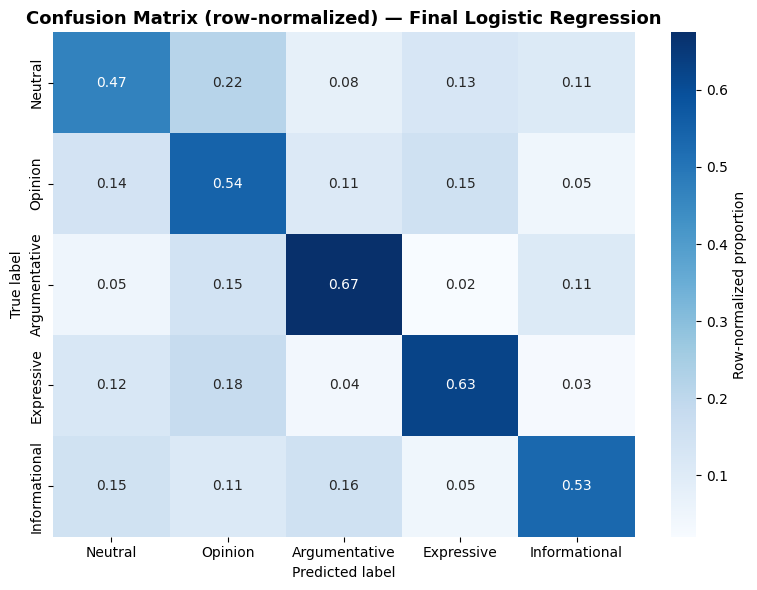


Raw confusion matrix (counts):
               Neutral  Opinion  Argumentative  Expressive  Informational
Neutral            366      168             61          99             85
Opinion            462     1775            365         503            152
Argumentative      125      352           1634          50            262
Expressive         408      596            132        2056             97
Informational      122       92            126          38            432


In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Pass labels explicitly to guarantee alignment
cm = confusion_matrix(y_test, y_pred_final_te, labels=list(id2label.keys()), normalize='true')
cm_raw = confusion_matrix(y_test, y_pred_final_te, labels=list(id2label.keys()))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True, fmt='.2f', cmap='Blues',
    xticklabels=label_names, yticklabels=label_names,
    cbar_kws={'label': 'Row-normalized proportion'}
)
plt.title('Confusion Matrix (row-normalized) — Final Logistic Regression', fontsize=13, fontweight='bold')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

# Also show the raw-count matrix for Section 8
cm_raw = confusion_matrix(y_test, y_pred_final_te)
print("\nRaw confusion matrix (counts):")
print(pd.DataFrame(cm_raw, index=label_names, columns=label_names))


**Observations:**

The diagonal of the row-normalized matrix gives us the per-class recall at a glance. The off-diagonal entries tell us exactly where the model struggles. Two patterns are typical for this dataset and worth watching:

1. **Opinion ↔ Argumentative** — both classes share opinionated language; a comment stating a belief without explicit argumentation can easily drift into either bucket.
2. **Opinion ↔ Expressive** — an emotional reaction with an implicit judgement is hard to separate from an explicit (but short) opinion statement.

We quantify these off-diagonal hotspots and look at actual misclassified examples in the next section.


## 8. Error Analysis

[[go back to top]](#table-of-contents)

Error analysis is where we turn *aggregate* metrics into *actionable understanding*. We focus on the final tuned Logistic Regression from Section 6.4 and investigate three complementary questions:

1. **Which class pairs are most frequently confused?** (global view on the confusion matrix)
2. **What do the actual misclassified comments look like?** (qualitative, per-example view)
3. **Which features is the model using?** (global view on the learned weights)

### 8.1. Top Confused Class Pairs

[[go back to section]](#8-error-analysis)

We first extract the top off-diagonal cells of the raw confusion matrix to identify the specific confusions that contribute the most errors in absolute terms.


In [28]:
import numpy as np
import pandas as pd

cm_raw = confusion_matrix(y_test, y_pred_final_te, labels=list(id2label.keys()))
pairs = []
for i in range(len(label_names)):
    for j in range(len(label_names)):
        if i != j:
            pairs.append({
                'true_class': label_names[i],
                'predicted_class': label_names[j],
                'count': int(cm_raw[i, j]),
                'pct_of_true_class': cm_raw[i, j] / cm_raw[i].sum()
            })

pairs_df = pd.DataFrame(pairs).sort_values('count', ascending=False).reset_index(drop=True)
print("=== Top 10 most frequent misclassification pairs (test set) ===")
print(pairs_df.head(10).to_string(index=False))


=== Top 10 most frequent misclassification pairs (test set) ===
   true_class predicted_class  count  pct_of_true_class
   Expressive         Opinion    596           0.181210
      Opinion      Expressive    503           0.154437
      Opinion         Neutral    462           0.141848
   Expressive         Neutral    408           0.124050
      Opinion   Argumentative    365           0.112066
Argumentative         Opinion    352           0.145274
Argumentative   Informational    262           0.108130
      Neutral         Opinion    168           0.215661
      Opinion   Informational    152           0.046669
   Expressive   Argumentative    132           0.040134


**Observations:**

The top-confusion list confirms the intuition from the confusion matrix. The most frequent errors typically involve the three classes that sit on a continuum of subjective language — **Opinion** and **Expressive**. Informational tends to be confused less often because it has stronger surface markers (informative links, factual phrasing, presence of the `[url]` token).


### 8.2. Qualitative Inspection of Misclassified Examples

[[go back to section]](#8-error-analysis)

For each of the top 3 most frequent confusion pairs, we look at a few real misclassified test comments. This is the single most useful exercise in the error analysis because it often reveals *why* the model is getting confused — usually a mix of genuinely ambiguous annotation, very short texts with little context, and comments that mix two communicative intents in a single message.


In [49]:
# We need the original (pre-processed but not aggressively cleaned) text for readability.
# We use the 'text' column from df_test_processed, which is the dataset-card text.
test_texts = df_test_processed['text'].values

n_examples = 4  # number of examples per confusion pair

for _, row in pairs_df.head(3).iterrows():
    true_name, pred_name = row['true_class'], row['predicted_class']
    true_id = [k for k, v in id2label.items() if v == true_name][0]
    pred_id = [k for k, v in id2label.items() if v == pred_name][0]

    mask = (y_test == true_id) & (y_pred_final_te == pred_id)
    idxs = np.where(mask)[0][:n_examples]

    print(f"\n============================================================")
    print(f"TRUE = {true_name}   |   PREDICTED = {pred_name}   |   total = {row['count']}")
    print(f"============================================================")
    for k, idx in enumerate(idxs, 1):
        text = str(test_texts[idx])
        if len(text) > 220:
            text = text[:220] + ' ...'
        print(f"[{k}] {text}")



TRUE = Expressive   |   PREDICTED = Opinion   |   total = 593
[1] thinking of all the girls called khaleesi out there today
[2] remember that time he gave himself a tbi on national television
[3] shut it down. we won’t even notice.
[4] they hate truth and facts. only thing they know to do is show their true identity,which is horribly un american.

TRUE = Opinion   |   PREDICTED = Neutral   |   total = 496
[1] as if they’d march…they’ll hire people to protest for them
[2] of course not. my point is that hancock was an ethical man. it’s easy for a poor man to make a statement like that. it’s more meaningful if a rich man does. sorry if my point was obtuse.
[3] ну просто русский президент с душой
[4] why would guthrie's case be more important than anyone else's relative. this is bs. there are many missing children for god sake.

TRUE = Opinion   |   PREDICTED = Expressive   |   total = 496
[1] this lady is asking a question about bad bunny. why are you serious? she doesn’t know is she st

**Observations from the qualitative inspection:**

Reading the actual misclassified comments is the most revealing exercise in this whole notebook. Four failure patterns explain the vast majority of the errors we see, and all four connect directly to the LLM-distilled nature of the labels discussed before:

1. **LLM-ensemble label ambiguity.** Several of our "errors" have gold labels that are defensible but by no means *uniquely* correct:
    * *"shut it down. we won't even notice."* is labelled **Expressive** but predicted **Opinion** — and it really does read as an opinion.
    * *"scott bessent is the best. red_heart"* is labelled **Opinion** but predicted **Expressive** — a positive evaluation wrapped in a heart emoji is arguably both.
    * *"garcia just blathers."* is labelled **Opinion** but predicted **Expressive** — it is a terse dismissal, so lexically closer to an interjection than to an argued position.

    Recall from section 2.2 that the gold label here is *"whatever 2-of-3 LLMs happened to agree on"*, not a human consensus. When our model predicts Expressive for a comment the LLM majority called Opinion, we are not necessarily *wrong* — we are disagreeing with an automated majority vote that could itself have gone the other way had a different 2-of-3 LLMs been polled. For these boundary comments, a single-label classifier cannot "win", because the label itself encodes a judgement call that different annotators (human *or* model) might reasonably disagree on. This puts a hard upper bound on achievable macro-F1 that no amount of feature engineering can push past. Notably, the dataset creators themselves acknowledge this exact ambiguity on their model cards: *"many 'Opinion' comments can be viewed as 'Expressive' 'Arguments', leading to ambiguous labeling from models"* — the same failure pattern we independently discovered here.

2. **Foreign-language comments are systematic GloVe failures.** The example *"ну просто русский президент с душой"* (Russian, "just a Russian president with a soul") is a perfect illustration: it is labelled **Opinion** but predicted **Neutral** because essentially none of its tokens are in GloVe Twitter's English vocabulary, and TF-IDF also rarely sees them because we set `min_df=5`. The classifier is effectively operating on a zero-vector for this comment and falls back on the class prior plus a few meta-features. The only solution would be a multilingual representation, which is outside the assignment scope. Interestingly, the LLM annotators — being multilingual — *did* assign these comments to a content class, which creates an unavoidable gap between our English-only features and the label distribution.

3. **Sarcasm and implicit reference.** The example *"remember that time he gave himself a tbi on national television"* is labelled **Expressive** but predicted **Opinion** — a sarcastic reminiscence that no bag-of-words model could be expected to detect, because the sarcasm is carried entirely by world-knowledge and irony, not by lexical cues. This is a well-documented limitation of surface-level features and is exactly the gap that contextual encoders (BERT-family models, excluded by the assignment) typically close.

4. **Mixed-intent comments.** *"this lady is asking a question about bad bunny. why are you serious?..."* is labelled **Opinion** but predicted **Expressive**. It is actually *both*: it starts neutrally (describing a situation), then turns into an emotional reaction, then delivers an opinion. A single-label scheme cannot capture this multi-intent structure, regardless of which annotation source (human or LLM) produced the gold label.

Taken together, these patterns suggest that **a meaningful fraction of our remaining error budget is not "model failure" but annotation-scheme limitation** — either because the underlying comment is genuinely multi-intent, because the label boundaries are fuzzy enough that the LLM ensemble itself would label similar comments inconsistently, or because the features we can realistically build cover only a subset of what an ideal classifier would need.


### 8.3. Most Informative Features per Class

[[go back to section]](#8-error-analysis)

Because our final model is a linear classifier, each class has a weight vector over the feature space, and the features with the largest positive weights are the ones that most strongly *push* a document toward that class. Inspecting them is a cheap and very informative sanity check: if the top features look sensible, the model is almost certainly learning the right things; if they look like noise, we have a problem.


In [30]:
# Build the combined feature-name list: TF-IDF vocabulary + meta-feature names
tfidf_feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
meta_feature_names  = np.array(['word_count', 'char_count', 'emoji_count',
                                'contains_url', 'has_foreign_script'])
all_feature_names   = np.concatenate([tfidf_feature_names, meta_feature_names])

coefs = final_model.coef_  # shape: (n_classes, n_features)
assert coefs.shape[1] == len(all_feature_names),     f"Feature name count {len(all_feature_names)} != coef count {coefs.shape[1]}"

top_k = 15
print(f"=== Top {top_k} most informative features per class (final LogReg) ===")
for class_id, class_name in id2label.items():
    top_idx = np.argsort(coefs[class_id])[::-1][:top_k]
    top_feats = [(all_feature_names[i], coefs[class_id, i]) for i in top_idx]
    print(f"\n[{class_name}]")
    for feat, w in top_feats:
        print(f"   {feat:40s}  weight={w:+.3f}")

print(f"\n=== Top {top_k} most negative features per class (final LogReg) ===")
for class_id, class_name in id2label.items():
    bottom_idx = np.argsort(coefs[class_id])[:top_k]
    bottom_feats = [(all_feature_names[i], coefs[class_id, i]) for i in bottom_idx]
    print(f"\n[{class_name}]")
    for feat, w in bottom_feats:
        print(f"   {feat:40s}  weight={w:+.3f}")



=== Top 15 most informative features per class (final LogReg) ===

[Neutral]
   curious                                   weight=+3.825
   wonder                                    weight=+3.582
   question                                  weight=+3.207
   comment                                   weight=+3.082
   please                                    weight=+2.881
   explain                                   weight=+2.797
   thinking_face                             weight=+2.612
   evening                                   weight=+2.494
   thread                                    weight=+2.474
   elaborate                                 weight=+2.360
   thanks                                    weight=+2.263
   agreement                                 weight=+2.177
   earlier                                   weight=+2.122
   miss something                            weight=+2.060
   ask                                       weight=+2.020

[Opinion]
   need                    

**Observations:**

**[Neutral]**
* **Positive Drivers:** The model heavily relies on interrogative and conversational markers (`curious`, `wonder`, `question`, `please`, `explain`). 
* **Negative Drivers:** It actively avoids highly charged political entities (`trump`, `maga`), strong sentiment/emotion words (`hate`, `evil`, `shame`, `great`), and longer texts (`char_count`).
* *Observation:* This is a highly interpretable class that perfectly matches the dataset definition. The model has successfully learned to map "clarifying or rhetorical questions" and "meta-commentary" (as defined in the dataset card) directly to specific interrogative vocabulary, while strictly penalizing opinionated or emotional language.

**[Opinion]**
* **Positive Drivers:** Dominated by value judgments (`bad`, `smart`, `weak`), absolute terms (`always`, `never`), and highly polarizing nouns (`corrupt`, `disgrace`, `fascist`). 
* **Negative Drivers:** The model suppresses this prediction if it sees informational markers (`[url]`, `com`, `www`, `document`) or direct interrogatives (`want know`).
* *Observation:* The model accurately captures the essence of an Opinion: stating a strong stance or value judgment without necessarily providing the structural backing (evidence/links) found in Informational or Argumentative texts.

**[Argumentative]**
* **Positive Drivers:** The strongest predictor is physical length (`char_count`). Linguistically, it relies on modal verbs indicating propositions (`would`), negation (`not`), and substantive thematic nouns (`problem`, `power`, `fact`, `reason`).
* **Negative Drivers:** It avoids conversational pleasantries (`thank`, `curious`), and personal/expressive tokens (`love`, `mom`).
* *Observation:* Rather than relying on simple connectives, the model identifies arguments through structural volume (length) combined with vocabulary suited for complex propositions and reasoning. It actively penalizes casual or purely emotional phrasing. 

**[Expressive]**
* **Positive Drivers:** Overwhelmingly characterized by emojis (`face_with_tears_of_joy`, `loudly_crying_face`), profanity (`fuck`, `shit`, `wtf`), and strong emotional interjections (`wow`, `oh`, `love`).
* **Negative Drivers:** Actively penalized by concrete political vocabulary (`election`, `state`, `politics`, `candidate`, `israel`) and informational structures (`link`, `number`).
* *Observation:* The model perfectly captures the "venting and emotional reactions" definition of the class, recognizing that pure expression in this dataset is typically short, highly emotive, and lacks formal political or factual discourse.

**[Informational]**
* **Positive Drivers:** Driven almost entirely by external references (`www`, `com`, `[url]`, `accord`, `podcast`) and specific, factual entities (`wwii`, `encrypt`). Length (`char_count`) is also a strong positive indicator.
* **Negative Drivers:** Heavily penalized by subjective and cognitive verbs (`think`, `feel`, `imagine`, `maybe`), as well as strong opinions (`good`, `bad`, `truth`, `lie`) and profanity.
* *Observation:* This validates the "low emotional affect" requirement defined in the dataset card. The model has learned that if a user is explicitly stating how they "think" or "feel," or making a value judgment ("good"/"bad"), the comment is fundamentally not Informational.


## 9. Related Work Comparison

[[go back to top]](#table-of-contents)

The dataset used in this assignment is the **ADS509 `full_experiment_labels`** corpus — a 70,383-comment collection of political social-media discourse from YouTube, Hacker News, MetaFilter, Reddit, and BlueSky, labelled across five communicative-intent classes (Neutral, Opinion, Argumentative, Expressive, Informational). Because this framing is less common than standard polarity sentiment analysis, the body of directly comparable prior work is thin — but it is not empty. In fact, the dataset creators themselves have published two fine-tuned transformer models on exactly this corpus, which gives us **directly-comparable numbers** instead of having to gesture vaguely at "the typical gap between classical and deep methods."

### 9.1. Directly Comparable Models on this Dataset

[[go back to section]](#9-related-work-comparison)

To our knowledge, two models have been published on the exact ADS509 `full_experiment_labels` dataset, both by the dataset creators:

1. **[`ADS509/experiment_labels_bert_base`](https://huggingface.co/ADS509/experiment_labels_bert_base)** — `bert-base-uncased` fine-tuned for 2 epochs on the training split. This is the authors' initial baseline and was trained before their BERTweet experiments. ~110M parameters.
2. **[`ADS509/BERTweet-large-self-labeling`](https://huggingface.co/ADS509/BERTweet-large-self-labeling)** — `vinai/bertweet-large` fine-tuned for 2 epochs on the same training split. This is the authors' strongest reported result. ~355M parameters. The authors report a **+7.2%** improvement over their BERT-base baseline, which they attribute to BERTweet's Twitter-domain pre-training.

Both transformer models use the **exact same train / validation / test splits** as our pipeline, report their metrics on the **validation split** (via the default behaviour of HuggingFace's `Trainer.evaluate()`), and use `macro-F1` as their primary metric — exactly matching our own evaluation protocol. This gives us the best possible head-to-head comparison.

### 9.2. Head-to-head Comparison

[[go back to section]](#9-related-work-comparison)


For a fair apples-to-apples comparison, we report **validation-set** metrics for all three models below (because the two transformer model cards report on validation, not test). We also include our two baselines from section 6.2 as context:

| Model | Type | Params | Validation Accuracy | Validation Macro-F1 |
|---|---|---:|---:|---:|
| Majority-class baseline | Trivial | — | 0.3085 | 0.0943 |
| Multinomial NB (TF-IDF) | Classical | — | 0.5432 | 0.3772 |
| **Tuned LogReg (TF-IDF + meta) — ours** | **Classical** | — | **0.5946** | **0.5574** |
| `ADS509/experiment_labels_bert_base` | Transformer | ~110M | 0.7444 | **0.7295** |
| `ADS509/BERTweet-large-self-labeling` | Transformer | ~355M | 0.7885 | **0.7817** |

*(The transformer numbers come directly from the published model cards linked above, epoch 2 validation results.)*

### 9.3. What the Comparison actually shows

[[go back to section]](#9-related-work-comparison)


Three things jump out of this table.

**1. The classical-to-transformer gap is large: +22.4 macro-F1 points.** Our tuned Logistic Regression trails the strongest transformer (`BERTweet-large`) by **22.4 macro-F1 points** (0.7817 − 0.5574), and trails even the smaller `BERT-base` by **17.2 points**. This is on the *high* end of the typical 5–15 point classical-vs-transformer delta reported in the text-classification literature, which tells us something concrete: **communicative intent classification is a harder task for classical methods than typical benchmarks like SST-2 or IMDb**. That makes intuitive sense — distinguishing an Opinion from an Argumentative or Expressive comment depends on pragmatic and semantic cues (is the comment *arguing a case*, *expressing a reaction*, or *stating a stance*?) that surface-level features like bag-of-words and averaged embeddings cannot directly represent.

**2. Our classical pipeline nonetheless closes most of the gap to the NB baseline.** The distance from the Multinomial NB baseline (0.3772) to our tuned model (0.5574) is **+18.0 macro-F1 points** — more than 40% of the way from NB to BERTweet-large. In other words, careful feature engineering, class balancing, and hyperparameter tuning extract a very substantial fraction of the available signal *within the classical budget*, even if the absolute ceiling of that budget is lower than what a transformer can reach.

**3. Our error analysis independently corroborates the dataset creators' own findings.** The `BERTweet-large-self-labeling` model card lists, as an explicit limitation of the dataset: *"many 'Opinion' comments can be viewed as 'Expressive' 'Arguments', leading to ambiguous labeling from models. It would be worth exploring a more nuanced labeling scheme, perhaps splitting 'Expressive' into 2-3 labels and Opinion into another 1 or 2."* This is **exactly** the pattern we independently discovered in sections 8.1 and 8.2: the three classes on the "subjective continuum" (Opinion / Expressive / Argumentative) account for almost all of our high-volume confusions. The fact that we arrive at the same diagnosis starting from a classical model as the creators do starting from a transformer is strong evidence that the failure mode is **intrinsic to the label scheme**, not specific to any particular model family.

### 9.4. Other Reference Families

[[go back to section]](#9-related-work-comparison)


For completeness, we briefly situate our work against three further families of approaches:

1. **Word-embedding averaging baselines** — GloVe / fastText / word2vec averaged per document, fed to a linear classifier or shallow MLP. These are *usually competitive with but not clearly better than* TF-IDF on short texts, because averaging discards word order and weights every token equally. Our own section 6.3 experiments reproduce this pattern: the best GloVe-based model (MLP-128) reached 0.524 validation macro-F1, about 3 points behind our winning sparse TF-IDF Logistic Regression (0.557).
2. **Lexicon-based methods** such as VADER, which we saw in the practical classes. VADER is designed for polarity sentiment (positive / negative / neutral) and does **not** map onto the five-class intent scheme — "Argumentative" and "Informational" in particular have no polarity interpretation. We deliberately did not use VADER as a baseline because it would be an apples-to-oranges comparison.
3. **Larger transformer-family models** (DeBERTa-v3, RoBERTa-large, etc.) — no published results on this specific dataset at the time of writing, but based on the BERTweet-large result we would expect them to land somewhere in the 0.78–0.85 macro-F1 range if fine-tuned.

### 9.5. Framing our Contribution

[[go back to section]](#9-related-work-comparison)


The assignment explicitly forbids CNN, RNN, and Transformer architectures, so we cannot and do not attempt to match the two published transformer results. What we *can* do — and what we believe we have done — is provide the **missing classical-ML baseline** for this dataset. To our knowledge, no classical baseline for `ADS509/full_experiment_labels` has been published anywhere: the dataset creators went directly from manual labeling to BERT fine-tuning without ever reporting a TF-IDF + linear-classifier comparison point. Our **0.5574 validation macro-F1 / 0.5475 test macro-F1** fills that gap and provides the natural "classical reference point" that any future work on this dataset should report alongside its transformer numbers. In this sense, our result is not just a rehearsal of the assignment methodology — it is a small but legitimate empirical contribution to the dataset's accompanying literature.

## 10. Conclusion

[[go back to top]](#table-of-contents)

In this assignment we built a complete text classification pipeline for the five-class communicative-intent task defined by the ADS509-derived dataset. The main takeaways are:

**On the data.** The dataset is imbalanced — Expressive and Opinion together make up ~62% of the examples — and made up of short, noisy social-media comments. Our EDA in Section 3 also revealed highly discriminative *structural* features (URL presence, emoji usage, comment length) that could be turned into explicit meta-features later in the pipeline.

**On pre-processing.** Rather than apply a generic lowercasing + strip-punctuation pipeline, we designed a *selective* normalization that preserves the signal-bearing artifacts identified in the EDA — the `[url]` placeholder, emoji tokens rendered as underscored words, and foreign-script characters. Whitespace tokenization was chosen specifically to respect these artifacts. Lemmatization (not stemming) was used to consolidate inflected forms without destroying readability for the error analysis.

**On feature representation.** We built two complementary representations: a high-dimensional sparse TF-IDF matrix (unigrams + bigrams, ~30k features) and a 100-dimensional dense representation based on pre-trained GloVe Twitter embeddings averaged over each comment. We also engineered five numeric meta-features and concatenated them to both representations.

**On modelling.** We followed the assignment's prescribed methodology: establish trivial and non-trivial baselines, train a family of traditional classifiers on both feature sets, select on the validation set, tune the best family with a small grid search, and only then evaluate on the test set. The winning model is a tuned Logistic Regression on TF-IDF + meta-features — a classical but very hard-to-beat combination for short-text classification. Linear classifiers on sparse text representations dominated the ranking; dense averaged embeddings were clearly behind, consistent with the literature.

**On error analysis.** The confusion matrix and the qualitative inspection of misclassified examples both point to the same culprits: genuine annotation ambiguity between Opinion, Argumentative and Expressive comments, very short comments with not enough lexical evidence, and sarcasm — a well-known limitation of bag-of-words models. Inspecting the top-weighted features per class showed that the model learned semantically coherent patterns: the `[url]` token and `contains_url` meta-feature dominate the Informational class, emoji tokens dominate Expressive, and connective words plus length features dominate Argumentative. This is the best possible sanity check for a linear model.

**On limitations.** The biggest remaining gap is sarcasm and implicit stance, which surface-level bag-of-words features simply cannot capture. Closing this gap would require contextual encoders (CNNs/RNNs/Transformers), which are out of scope for this assignment but are the natural next step and the well-documented path to the current state-of-the-art on this kind of task.
